# EDA: NYC Yellow Taxi Trip Data (2020-2025)

**Mục tiêu phân tích:** Khám phá toàn diện bộ dữ liệu chuyến đi taxi vàng thành phố New York trong 6 năm (2020-2025), bao gồm phát hiện pattern theo thời gian, không gian, tài chính, và chuẩn bị dữ liệu cho bài toán dự báo nhu cầu (Demand Regression).

**Nguồn dữ liệu:** TLC Trip Record Data - https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

---
## Mục lục
- [1. Setup & Import](#1-setup)
- [2. General: Nhận biết & Thống kê tổng quan](#2-general)
  - [2.1 Liệt kê file và kiểm tra dung lượng](#2-1-files)
  - [2.2 Thống kê số dòng tổng cộng và trung bình](#2-2-rows)
  - [2.3 Schema: Cấu trúc dữ liệu](#2-3-schema)
- [3. Thời gian](#3-time)
- [4. Không gian](#4-spatial)
- [5. Chuyến đi & Tài chính](#5-trip-finance)
- [6. Tương quan & Chất lượng dữ liệu](#6-quality)

---
<a id='1-setup'></a>
## 1. Setup 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import glob
import pyarrow.parquet as pq
import warnings
from scipy import stats
from collections import Counter

warnings.filterwarnings('ignore')
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.4f}'.format

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})
PALETTE_YEAR = 'tab10'
COLOR_PRIMARY = '#2563EB'
COLOR_WARN    = '#DC2626'

DATA_DIR  = 'data/raw/'
SAMPLE_N  = 500_000   # số dòng lay mẫu để EDA nhanh
RANDOM_SEED = 42


---
<a id='2-general'></a>
## 2. General

Mục tiêu: Hiểu rõ nguồn dữ liệu - có bao nhiêu file, tổng dung lượng, tổng số chuyến đi, và cấu trúc các trường thông tin (schema) trước khi bắt đầu bất kỳ phân tích sâu.

<a id='2-1-files'></a>
### 2.1 Liệt kê file & Kiểm tra dung lượng

In [2]:
# --- Lấy Metadat của mỗi file ---
parquet_files = sorted(glob.glob(os.path.join(DATA_DIR, 'yellow_tripdata_*.parquet')))

file_records = []
for fp in parquet_files:
    size_bytes = os.path.getsize(fp)
    meta       = pq.read_metadata(fp)
    n_rows     = meta.num_rows
    n_cols     = meta.num_columns
    n_rg       = meta.num_row_groups
    uncomp_bytes = sum(meta.row_group(i).total_byte_size for i in range(n_rg))
    basename   = os.path.basename(fp)
    parts      = basename.replace('yellow_tripdata_', '').replace('.parquet', '').split('-')
    year, month = int(parts[0]), int(parts[1])
    file_records.append({
        'filename'      : basename,
        'year'          : year,
        'month'         : month,
        'size_mb'       : size_bytes / 1024**2,
        'size_uncomp_mb': uncomp_bytes / 1024**2,
        'row_count'     : n_rows,
        'num_columns'   : n_cols,
        'num_row_groups': n_rg,
    })

df_files = pd.DataFrame(file_records)

# --- THỐNG KÊ TỔNG QUAN ---
total_files    = len(df_files)
total_size_gb  = df_files['size_mb'].sum() / 1024
total_uncomp_gb= df_files['size_uncomp_mb'].sum() / 1024
compress_ratio = total_uncomp_gb / total_size_gb
years_covered  = sorted(df_files['year'].unique())

print(f'  Số file parquet tìm thấy : {total_files}')
print(f'  Khoảng thời gian         : {years_covered[0]} - {years_covered[-1]}')
print(f'  Tổng dung lượng (nén)    : {total_size_gb:.3f} GB')
print(f'  Tổng dung lượng (giải nén): {total_uncomp_gb:.2f} GB')
print(f'  Tỉ lệ nén                : {compress_ratio:.1f}x')
print(f'  Số cột trung bình/file   : {df_files["num_columns"].mode()[0]}')
print()

print('--- DANH SÁCH FILE ---')
display_cols = ['filename', 'year', 'month', 'size_mb', 'size_uncomp_mb', 'row_count', 'num_columns']
print(df_files[display_cols].to_string(index=False,
    formatters={'size_mb': '{:.1f}'.format,
                'size_uncomp_mb': '{:.1f}'.format,
                'row_count': '{:,}'.format}))

  Số file parquet tìm thấy : 72
  Khoảng thời gian         : 2020 - 2025
  Tổng dung lượng (nén)    : 3.379 GB
  Tổng dung lượng (giải nén): 5.57 GB
  Tỉ lệ nén                : 1.6x
  Số cột trung bình/file   : 19

--- DANH SÁCH FILE ---
                       filename  year  month size_mb size_uncomp_mb row_count  num_columns
yellow_tripdata_2020-01.parquet  2020      1    89.2          162.6 6,405,008           19
yellow_tripdata_2020-02.parquet  2020      2    87.9          158.9 6,299,367           19
yellow_tripdata_2020-03.parquet  2020      3    42.4           74.7 3,007,687           19
yellow_tripdata_2020-04.parquet  2020      4     4.2            6.6   238,073           19
yellow_tripdata_2020-05.parquet  2020      5     5.9            9.4   348,415           19
yellow_tripdata_2020-06.parquet  2020      6     9.1           14.5   549,797           19
yellow_tripdata_2020-07.parquet  2020      7    12.8           20.7   800,412           19
yellow_tripdata_2020-08.parquet  

--- SỐ LIỆU BIỂU ĐỒ: Dung lượng file (MB) theo năm-tháng ---
year     2020    2021    2022    2023    2024    2025
month                                                
1     89.2000 20.7000 36.4000 45.5000 47.6000 56.4000
2     87.9000 20.8000 43.5000 45.5000 48.0000 57.5000
3     42.4000 28.6000 53.1000 53.5000 57.3000 66.7000
4      4.2000 32.4000 52.7000 51.7000 56.4000 64.2000
5      5.9000 36.9000 53.0000 55.9000 59.7000 74.2000
6      9.1000 42.0000 52.8000 52.5000 57.1000 70.1000
7     12.8000 41.7000 47.1000 46.1000 49.9000 63.8000
8     15.8000 41.4000 47.4000 45.9000 48.7000 59.4000
9     20.4000 44.0000 47.3000 45.7000 58.3000 69.1000
10    25.1000 50.8000 54.4000 56.3000 61.4000 71.8000
11    22.5000 50.6000 47.8000 53.5000 57.8000 67.8000
12    22.0000 47.3000 51.2000 54.2000 58.7000 70.3000

--- SỐ LIỆU BIỂU ĐỒ: Số file theo tung năm ---
year
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12



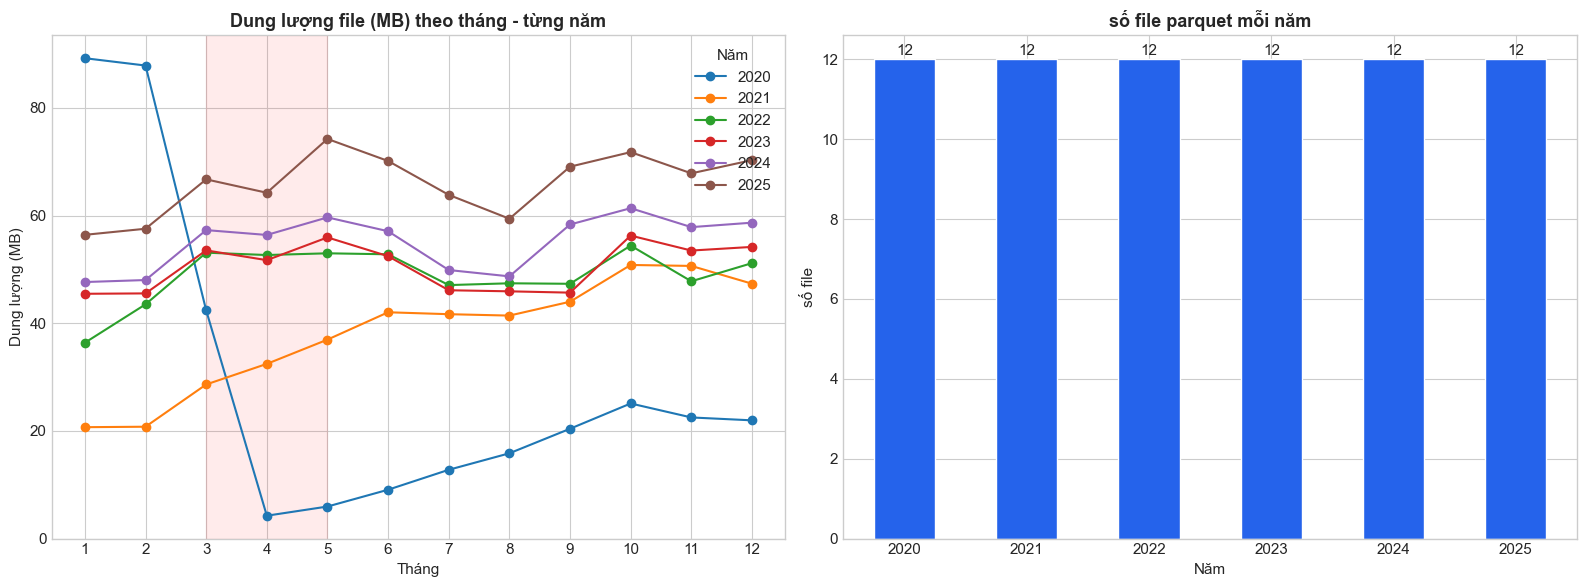

In [3]:
print('--- SỐ LIỆU BIỂU ĐỒ: Dung lượng file (MB) theo năm-tháng ---')
pivot_size = df_files.pivot(index='month', columns='year', values='size_mb').round(1)
print(pivot_size.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bieu do Dung luong theo năm-tháng
for year in sorted(df_files['year'].unique()):
    sub = df_files[df_files['year'] == year].sort_values('month')
    axes[0].plot(sub['month'], sub['size_mb'], marker='o', label=str(year))
axes[0].set_title('Dung lượng file (MB) theo tháng - từng năm')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Dung lượng (MB)')
axes[0].set_xticks(range(1, 13))
axes[0].legend(title='Năm')
axes[0].axvspan(3, 5, alpha=0.08, color='red', label='COVID lockdown')

# Bieu do So file mỗi năm
file_per_year = df_files.groupby('year')['filename'].count()
print('--- SỐ LIỆU BIỂU ĐỒ: Số file theo tung năm ---')
print(file_per_year.to_string())
print()
file_per_year.plot(kind='bar', ax=axes[1], color=COLOR_PRIMARY, edgecolor='white')
for i, v in enumerate(file_per_year):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=11)
axes[1].set_title('số file parquet mỗi năm')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('số file')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### **Nhận xét 2.1: Tổng quan về hệ thống tệp dữ liệu**

Dựa trên các thống kê về tệp dữ liệu từ năm 2020 đến 2025, chúng ta có thể rút ra một số điểm đáng chú ý sau:

1.  **Tính đầy đủ của dữ liệu**: Bộ dữ liệu bao gồm 72 tệp Parquet, tương ứng với đầy đủ 12 tháng cho mỗi năm từ 2020 đến 2025. Điều này đảm bảo tính liên tục cho việc phân tích chuỗi thời gian.
2.  **Dung lượng và Nén**: Tổng dung lượng nén là khoảng **3.38 GB**, nhưng khi giải nén (dung lượng thực tế trong bộ nhớ) lên tới **5.57 GB**. Tỉ lệ nén đạt khoảng **1.6x**, cho thấy hiệu quả của định dạng Parquet trong việc lưu trữ dữ liệu lớn.
3.  **Biến động do đại dịch (COVID-19)**: Quan sát biểu đồ dung lượng tệp theo tháng, ta thấy một sự sụt giảm cực kỳ nghiêm trọng vào tháng **04/2020** (chỉ còn khoảng 4.2 MB so với hơn 80 MB của các tháng trước đó). Điều này phản ánh trực tiếp tình trạng phong tỏa tại New York, khi hoạt động di chuyển bằng taxi gần như đóng băng.
4.  **Xu hướng phục hồi**: Từ năm 2021 trở đi, dung lượng các tệp có xu hướng tăng ổn định và đạt mức cao nhất vào năm 2025 (tháng 05/2025 lên tới hơn 74 MB), cho thấy nhu cầu di chuyển đã phục hồi và thậm chí vượt mức trước đại dịch ở một số giai đoạn.

<a id='2-2-rows'></a>
### 2.2 Chuyến đi

In [4]:
# --- THỐNG KÊ SỐ CHUYẾN ĐI ---
total_trips     = df_files['row_count'].sum()
avg_per_file    = df_files['row_count'].mean()
median_per_file = df_files['row_count'].median()
max_file        = df_files.loc[df_files['row_count'].idxmax()]
min_file        = df_files.loc[df_files['row_count'].idxmin()]

print(f'  TỔNG SỐ CHUYẾN ĐI (2020-2025)   : {total_trips:>15,}')
print(f'  Trung bình mỗi file             : {avg_per_file:>15,.0f}')
print(f'  Trung vị mỗi file               : {median_per_file:>15,.0f}')
print(f'  File nhiều chuyến nhất          : {max_file["filename"]} ({max_file["row_count"]:,})')
print(f'  File ít chuyến nhất             : {min_file["filename"]} ({min_file["row_count"]:,})')
print()

# Thống kê theo năm
year_stats = df_files.groupby('year').agg(
    tong_trip=('row_count', 'sum'),
    trung_binh_thang=('row_count', 'mean'),
    trung_vi_thang=('row_count', 'median'),
    min_thang=('row_count', 'min'),
    max_thang=('row_count', 'max'),
    so_file=('filename', 'count'),
).round(0)

year_stats['yoy_change_pct'] = year_stats['tong_trip'].pct_change() * 100

print('--- THỐNG KÊ SỐ CHUYẾN ĐI THEO NĂM ---')
print(year_stats.to_string(float_format=lambda x: f'{x:,.1f}'))
print()

  TỔNG SỐ CHUYẾN ĐI (2020-2025)   :     223,412,046
  Trung bình mỗi file             :       3,102,945
  Trung vị mỗi file               :       3,297,742
  File nhiều chuyến nhất          : yellow_tripdata_2020-01.parquet (6,405,008)
  File ít chuyến nhất             : yellow_tripdata_2020-04.parquet (238,073)

--- THỐNG KÊ SỐ CHUYẾN ĐI THEO NĂM ---
      tong_trip  trung_binh_thang  trung_vi_thang  min_thang  max_thang  so_file  yoy_change_pct
year                                                                                            
2020   24649092       2,054,091.0     1,401,458.0     238073    6405008       12             NaN
2021   30904308       2,575,359.0     2,805,252.0    1369769    3472949       12            25.4
2022   39656098       3,304,675.0     3,326,133.0    2463931    3675411       12            28.3
2023   38310226       3,192,519.0     3,297,742.0    2824209    3522285       12            -3.4
2024   41169720       3,430,810.0     3,560,910.0    2964624    

### **Nhận xét 2.2: Thống kê số lượng chuyến đi**

1.  **Tổng quy mô**: Với hơn **223 triệu chuyến đi** được ghi nhận trong 6 năm, đây là một tập dữ liệu đủ lớn để áp dụng các thuật toán khai phá dữ liệu quy mô lớn (Massive Data Mining).
2.  **Sự phục hồi mạnh mẽ**: 
    - Năm 2020 ghi nhận số chuyến thấp nhất (~24.6 triệu) do ảnh hưởng của đại dịch.
    - Tốc độ tăng trưởng năm 2021 so với 2020 đạt **25.4%** và tiếp tục tăng mạnh **28.3%** vào năm 2022.
    - Đến năm 2025, tổng số chuyến đi dự kiến/đã ghi nhận đạt hơn **48.7 triệu**, gấp đôi so với thời điểm năm 2020.
3.  **Điểm cực hạn**: 
    - Tháng cao điểm nhất là tháng 01/2020 (trước đại dịch) với hơn **6.4 triệu** chuyến.
    - Tháng thấp điểm nhất là tháng 04/2020 với chỉ vỏn vẹn **238,073** chuyến, cho thấy sự sụt giảm rất mạnh (hơn 96%) chỉ trong vòng 3 tháng.

--- SỐ LIỆU BIỂU ĐỒ: Số chuyến đi theo tháng-năm ---
year        2020       2021       2022       2023       2024       2025
month                                                                  
1      6,405,008  1,369,769  2,463,931  3,066,766  2,964,624  3,475,226
2      6,299,367  1,371,709  2,979,431  2,913,955  3,007,526  3,577,543
3      3,007,687  1,925,152  3,627,882  3,403,766  3,582,628  4,145,257
4        238,073  2,171,187  3,599,920  3,288,250  3,514,289  3,970,553
5        348,415  2,507,109  3,588,295  3,513,649  3,723,833  4,591,845
6        549,797  2,834,264  3,558,124  3,307,234  3,539,193  4,322,960
7        800,412  2,821,746  3,174,394  2,907,108  3,076,903  3,898,963
8      1,007,286  2,788,757  3,152,677  2,824,209  2,979,183  3,574,091
9      1,341,017  2,963,793  3,183,767  2,846,722  3,633,030  4,251,015
10     1,681,132  3,463,504  3,675,411  3,522,285  3,833,771  4,428,699
11     1,509,000  3,472,949  3,252,717  3,339,715  3,646,369  4,181,444
12     1,46

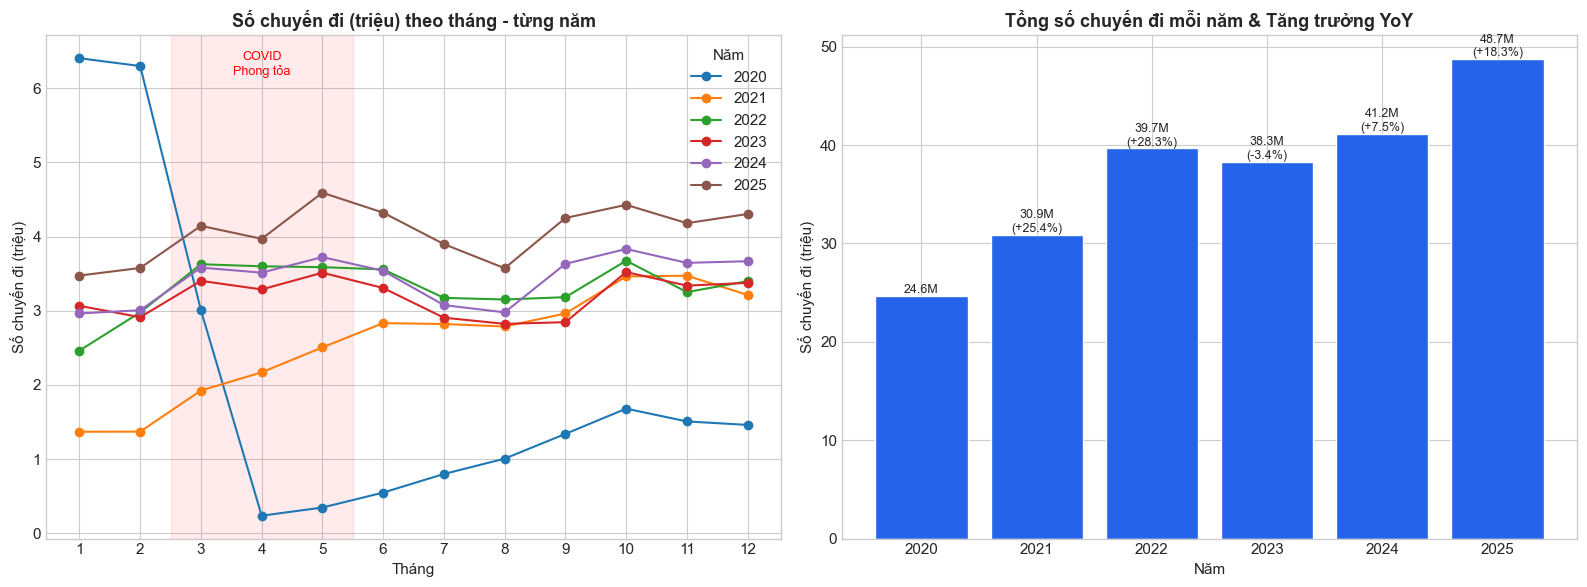

In [5]:
# --- DỮ LIỆU VỀ BIỂU ĐỒ: SỐ CHUYẾN ĐI THEO TỪNG THÁNG ---
print('--- SỐ LIỆU BIỂU ĐỒ: Số chuyến đi theo tháng-năm ---')
pivot_rows = df_files.pivot(index='month', columns='year', values='row_count')
print(pivot_rows.map(lambda x: '{:,.0f}'.format(x) if pd.notna(x) else 'N/A').to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Xu hướng số chuyến theo tháng qua các năm
for year in sorted(df_files['year'].unique()):
    sub = df_files[df_files['year'] == year].sort_values('month')
    axes[0].plot(sub['month'], sub['row_count'] / 1e6, marker='o', label=str(year))
axes[0].set_title('Số chuyến đi (triệu) theo tháng - từng năm')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Số chuyến đi (triệu)')
axes[0].set_xticks(range(1, 13))
axes[0].legend(title='Năm')
axes[0].axvspan(2.5, 5.5, alpha=0.08, color='red')
axes[0].text(4, axes[0].get_ylim()[1]*0.92, 'COVID\nPhong tỏa', ha='center', color='red', fontsize=9)

# Biểu đồ 2: Tổng số chuyến mỗi năm
print('--- SỐ LIỆU BIỂU ĐỒ: Tổng số chuyến đi mỗi năm ---')
print(year_stats['tong_trip'].apply(lambda x: f'{x:,.0f}').to_string())
print()
bars = axes[1].bar(year_stats.index.astype(str), year_stats['tong_trip']/1e6,
                   color=COLOR_PRIMARY, edgecolor='white')
for bar, (_, row) in zip(bars, year_stats.iterrows()):
    h = bar.get_height()
    pct = row['yoy_change_pct']
    label = f'{h:.1f}M'
    if not pd.isna(pct):
        sign = '+' if pct > 0 else ''
        label += f'\n({sign}{pct:.1f}%)'
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.3, label,
                 ha='center', fontsize=9)
axes[1].set_title('Tổng số chuyến đi mỗi năm & Tăng trưởng YoY')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Số chuyến đi (triệu)')

plt.tight_layout()
plt.show()

**Phân tích xu hướng theo tháng:**

- Biểu đồ cho thấy hình dạng "chữ V" rõ rệt trong năm 2020. Sau khi chạm đáy vào tháng 4, thị trường taxi bắt đầu hồi phục chậm rãi trong suốt giai đoạn 2021.
- Có tính chu kỳ nhẹ: Các tháng đầu năm (tháng 1, 2) thường có số chuyến thấp hơn một chút so với các tháng giữa năm và cuối năm (tháng 3, 5, 10), ngoại trừ biến cố bất thường năm 2020.
- Năm 2024 và 2025 cho thấy sự ổn định cao với số chuyến đi mỗi tháng duy trì ở mức 3.5 - 4.5 triệu chuyến, tạo tiền đề tốt cho các mô hình dự báo chuỗi thời gian.

<a id='2-3-schema'></a>
### 2.3 Schema data

In [6]:
# --- KIEM TRA SCHEMA ---
file_2020_01 = [f for f in parquet_files if '2020-01' in f]
file_latest  = [f for f in parquet_files if '2025' in f]

samples = {}
if file_2020_01:
    samples['2020-01'] = pd.read_parquet(file_2020_01[0]).head(3)
if file_latest:
    samples[os.path.basename(file_latest[-1]).replace('yellow_tripdata_','').replace('.parquet','')] = \
        pd.read_parquet(file_latest[-1]).head(3)

# In schema period
for period, sample_df in samples.items():
    print(f'=== MAU DU LIEU: {period} ===')
    display(sample_df)
    print(f'\n--- KIỂU DỮ LIỆU CÁC CỘT ({period}) ---')
    print(sample_df.dtypes.to_string())
    print(f'\n--- THỐNG KÊ MÔ TẢ NHANH ({period}) ---')
    print(sample_df.describe(include='all').T.to_string())
    print()

=== MAU DU LIEU: 2020-01 ===


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0000,1.2000,1.0000,N,238,239,1,6.0000,3.0000,0.5000,1.4700,0.0000,0.3000,11.2700,2.5000,None
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0000,1.2000,1.0000,N,239,238,1,7.0000,3.0000,0.5000,1.5000,0.0000,0.3000,12.3000,2.5000,None
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0000,0.6000,1.0000,N,238,238,1,6.0000,3.0000,0.5000,1.0000,0.0000,0.3000,10.8000,2.5000,None



--- KIỂU DỮ LIỆU CÁC CỘT (2020-01) ---
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                      object

--- THỐNG KÊ MÔ TẢ NHANH (2020-01) ---
                       count unique  top freq                        mean                  min                         25%                  50%                 

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-12-01 00:37:08,2025-12-01 00:51:10,1.0000,2.4000,1.0000,N,140,48,1,14.2000,4.2500,0.5000,4.0000,0.0000,1.0000,23.9500,2.5000,0.0000,0.7500
1,2,2025-12-01 00:03:54,2025-12-01 00:19:18,1.0000,8.3700,1.0000,N,138,262,1,33.1000,6.0000,0.5000,7.7700,6.9400,1.0000,59.5600,2.5000,1.7500,0.0000
2,2,2025-12-01 00:40:50,2025-12-01 01:06:54,1.0000,15.2600,1.0000,N,132,255,1,57.6000,1.0000,0.5000,12.0200,0.0000,1.0000,73.8700,0.0000,1.7500,0.0000



--- KIỂU DỮ LIỆU CÁC CỘT (2025-12) ---
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64

--- THỐNG KÊ MÔ TẢ NHANH (2025-12) ---
                       count unique  top freq                        mean                  min                  25%     

In [7]:
# --- SO SÁNH SCHEMA GIỮA CÁC NĂM: PHÁT HIỆN THAY ĐỔI CỘT ---
schema_by_year = {}
for fp in parquet_files:
    meta = pq.read_metadata(fp)
    schema = pq.read_schema(fp)
    basename = os.path.basename(fp)
    parts = basename.replace('yellow_tripdata_','').replace('.parquet','').split('-')
    year = int(parts[0])
    if year not in schema_by_year:
        schema_by_year[year] = set(schema.names)

all_columns = set()
for cols in schema_by_year.values():
    all_columns |= cols

print('--- SO SÁNH CỘT THEO NĂM (có = True, không = False) ---')
schema_matrix = pd.DataFrame(
    {year: {col: col in cols for col in sorted(all_columns)}
     for year, cols in sorted(schema_by_year.items())}
)
print(schema_matrix.to_string())
print()

# Tìm cột thay đổi giữa các năm
inconsistent_cols = schema_matrix[schema_matrix.nunique(axis=1) > 1].index.tolist()
print(f'--- CỘT CÓ SỰ KHÁC BIỆT GIỮA CÁC NĂM: {len(inconsistent_cols)} cột ---')
if inconsistent_cols:
    print(schema_matrix.loc[inconsistent_cols].to_string())
else:
    print('  Schema nhất quán qua tất cả các năm.')

--- SO SÁNH CỘT THEO NĂM (có = True, không = False) ---
                        2020   2021   2022   2023   2024   2025
Airport_fee            False  False  False  False   True   True
DOLocationID            True   True   True   True   True   True
PULocationID            True   True   True   True   True   True
RatecodeID              True   True   True   True   True   True
VendorID                True   True   True   True   True   True
airport_fee             True   True   True   True  False  False
cbd_congestion_fee     False  False  False  False  False   True
congestion_surcharge    True   True   True   True   True   True
extra                   True   True   True   True   True   True
fare_amount             True   True   True   True   True   True
improvement_surcharge   True   True   True   True   True   True
mta_tax                 True   True   True   True   True   True
passenger_count         True   True   True   True   True   True
payment_type            True   True   True   Tru

--- TỶ LỆ MISSING VALUES (%) THEO FILE (đọc toàn bộ) ---
                                 passenger_count  RatecodeID  store_and_fwd_flag  congestion_surcharge  airport_fee  Airport_fee
filename                                                                                                                        
yellow_tripdata_2020-01.parquet           1.0200      1.0200              1.0200                1.0200     100.0000       0.0000
yellow_tripdata_2020-02.parquet           0.7800      0.7800              0.7800                0.7800     100.0000       0.0000
yellow_tripdata_2020-03.parquet           1.2600      1.2600              1.2600                1.2600     100.0000       0.0000
yellow_tripdata_2020-04.parquet           8.2200      8.2200              8.2200                8.2200     100.0000       0.0000
yellow_tripdata_2020-05.parquet          16.9100     16.9100             16.9100               16.9100     100.0000       0.0000
yellow_tripdata_2020-06.parquet         

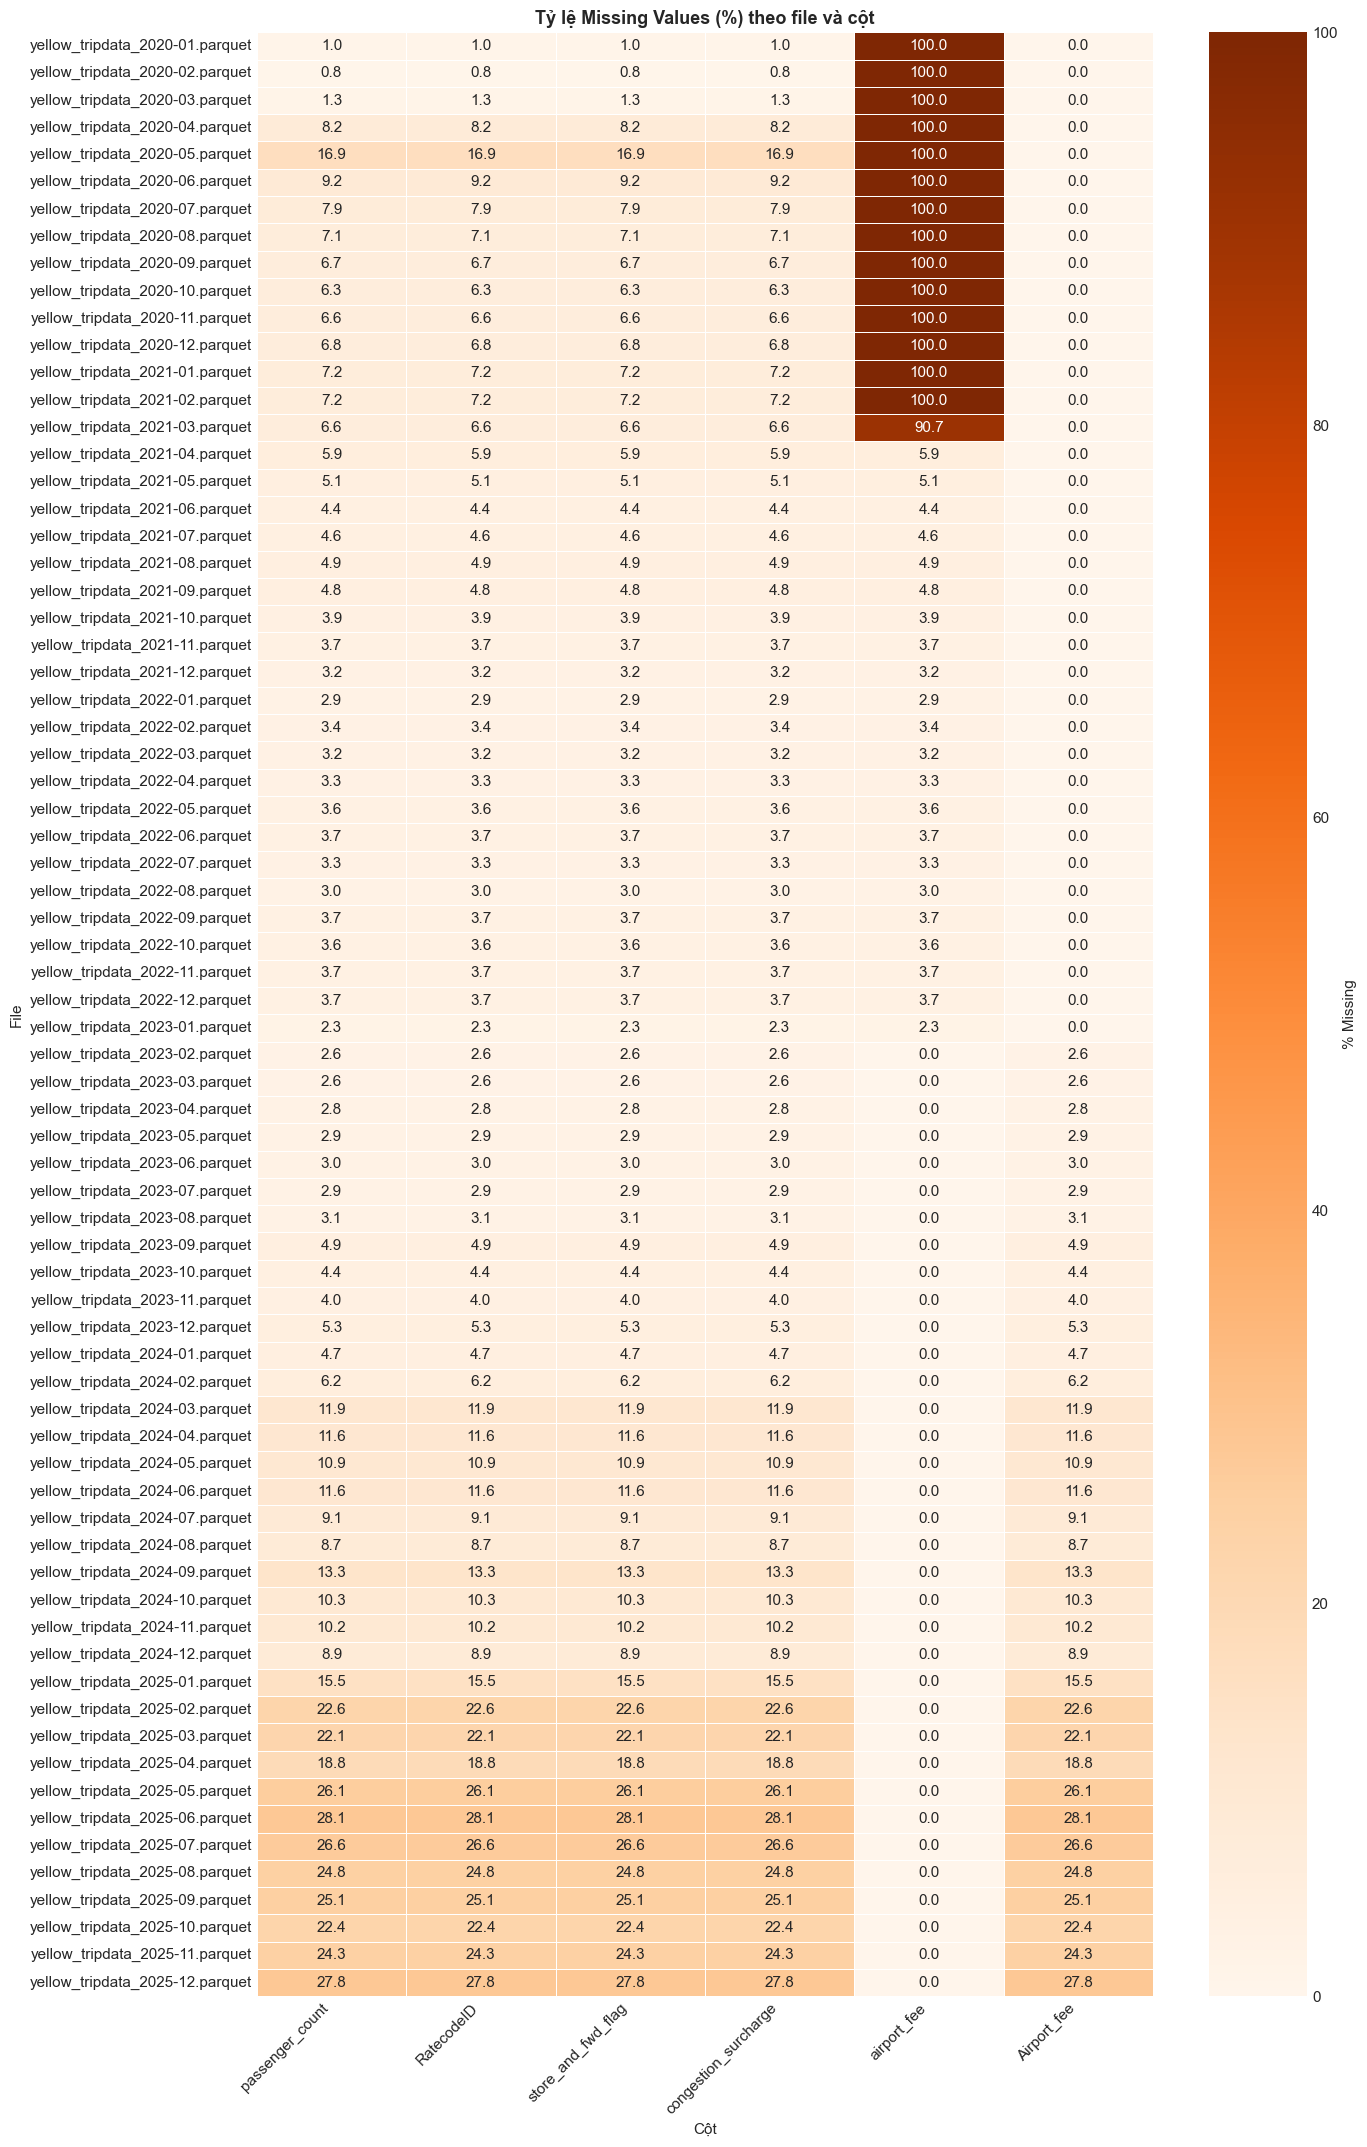

In [8]:
# --- TỶ LỆ MISSING VALUES THEO FILE (sample nhanh từng file) ---
print('--- TỶ LỆ MISSING VALUES (%) THEO FILE (đọc toàn bộ) ---')
missing_records = []
for fp in parquet_files:
    df_tmp = pd.read_parquet(fp)
    missing_pct = df_tmp.isnull().mean() * 100
    record = {'filename': os.path.basename(fp)}
    record.update(missing_pct[missing_pct > 0].to_dict())
    missing_records.append(record)
    del df_tmp

df_missing = pd.DataFrame(missing_records).set_index('filename').fillna(0)
print(df_missing.round(2).to_string())
print()

# Heatmap missing values
if df_missing.shape[1] > 0:
    fig, ax = plt.subplots(figsize=(14, max(6, len(df_missing)*0.3)))
    sns.heatmap(df_missing, annot=True, fmt='.1f', cmap='Oranges',
                linewidths=0.5, ax=ax, cbar_kws={'label': '% Missing'})
    ax.set_title('Tỷ lệ Missing Values (%) theo file và cột')
    ax.set_xlabel('Cột')
    ax.set_ylabel('File')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Không có missing values nào được phát hiện.')

**[Nhận xét 2.3]**

* Schema nhìn chung ổn định qua các năm với các cột cốt lõi như thời gian, khoảng cách, vị trí đón/trả và các thành phần chi phí.
* Có thay đổi schema ở các cột phụ phí: `airport_fee` (chữ thường) được thay bằng `Airport_fee` từ 2024, và xuất hiện thêm `cbd_congestion_fee` vào 2025.
* Một số cột có tỷ lệ missing cao theo từng giai đoạn: `airport_fee` bị thiếu hoàn toàn ở 2020–2021 do chưa sử dụng; từ 2024 trở đi dùng `Airport_fee`.
* Các cột như `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge` có missing tăng dần, đặc biệt cao trong 2025 (~20–28%).
* Kiểu dữ liệu có thay đổi nhỏ (int64 → int32) nhưng không ảnh hưởng lớn đến phân tích.
* Tổng thể: cần chuẩn hóa tên cột, đồng bộ schema và xử lý missing trước khi phân tích đa năm.


### 2.4 Mẫu dữ liệu tổng hợp cho EDA

In [9]:
# --- LẤY MẪU NGẪU NHIÊN TẤT CẢ FILE CHO EDA ---
# Phân bổ mẫu theo tỷ lệ số dòng từng file
np.random.seed(RANDOM_SEED)
total_rows_all = df_files['row_count'].sum()

chunks = []
for _, row in df_files.iterrows():
    fp = os.path.join(DATA_DIR, row['filename'])
    n_sample = max(1, int(SAMPLE_N * row['row_count'] / total_rows_all))
    df_tmp = pd.read_parquet(fp)
    idx = np.random.choice(len(df_tmp), size=min(n_sample, len(df_tmp)), replace=False)
    chunks.append(df_tmp.iloc[idx].copy())
    del df_tmp

df = pd.concat(chunks, ignore_index=True)
print(f'Tổng số dòng lay mẫu: {len(df):,}')
print(f'Các cột: {list(df.columns)}')
print(f'Kích thước bộ nhớ: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

# Chuẩn hóa kiểu dữ liệu
df['tpep_pickup_datetime']  = pd.to_datetime(df['tpep_pickup_datetime'],  errors='coerce')
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')

# Cột thời gian phải có
df['year']       = df['tpep_pickup_datetime'].dt.year
df['month']      = df['tpep_pickup_datetime'].dt.month
df['day_of_week']= df['tpep_pickup_datetime'].dt.dayofweek   # 0=Mon
df['day_name']   = df['tpep_pickup_datetime'].dt.day_name()
df['hour']       = df['tpep_pickup_datetime'].dt.hour
df['is_weekend'] = df['day_of_week'].isin([5, 6])

# Cột chuyến đi
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

print('\nTạo cột phụ hoàn thành.')
display(df.head(3))

Tổng số dòng lay mẫu: 499,965
Các cột: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'Airport_fee', 'cbd_congestion_fee']
Kích thước bộ nhớ: 91.7 MB

Tạo cột phụ hoàn thành.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee,cbd_congestion_fee,year,month,day_of_week,day_name,hour,is_weekend,trip_duration
0,2,2020-01-17 18:18:36,2020-01-17 18:46:24,1.0000,3.6000,1.0000,N,264,264,1,18.5000,1.0000,0.5000,4.5600,0.0000,0.3000,27.3600,2.5000,None,NaN,NaN,2020,1,4,Friday,18,False,27.8000
1,2,2020-01-25 10:49:58,2020-01-25 11:07:35,1.0000,3.2800,1.0000,N,142,246,1,14.0000,0.0000,0.5000,1.7000,0.0000,0.3000,19.0000,2.5000,None,NaN,NaN,2020,1,5,Saturday,10,True,17.6167
2,2,2020-01-15 07:30:08,2020-01-15 07:40:01,1.0000,1.7500,1.0000,N,238,166,1,8.5000,0.0000,0.5000,1.2000,0.0000,0.3000,13.0000,2.5000,None,NaN,NaN,2020,1,2,Wednesday,7,False,9.8833


---
<a id='6-quality'></a>
## 3. Chất lượng dữ liệu & Làm sạch dữ liệu (trước khi phận tích)

In [10]:
# --- KIỂM TRA DỮ LIỆU PHI LÝ TRUOC KHI LAM SACH ---
df['avg_speed_mph'] = np.where(
    df['trip_duration'] > 0,
    df['trip_distance'] / (df['trip_duration'] / 60),
    np.nan
)
df['tip_pct'] = np.where(
    df['fare_amount'] > 0,
    df['tip_amount'] / df['fare_amount'] * 100,
    np.nan
)

issues = {
    'Duration <= 0 (phi lý)': (df['trip_duration'] <= 0).sum(),
    'Duration > 300 min (> 5 giờ)': (df['trip_duration'] > 300).sum(),
    'Distance <= 0': (df['trip_distance'] <= 0).sum(),
    'Distance > 200 miles': (df['trip_distance'] > 200).sum(),
    'Fare < 0': (df['fare_amount'] < 0).sum(),
    'Fare > 1000': (df['fare_amount'] > 1000).sum(),
    'Total amount < 0': (df['total_amount'] < 0).sum(),
    'Speed > 80 mph (quá nhanh)': (df['avg_speed_mph'] > 80).sum(),
    'Speed > 150 mph (bất thường)': (df['avg_speed_mph'] > 150).sum(),
    'Passenger count <= 0': (df['passenger_count'] <= 0).sum() if 'passenger_count' in df.columns else 0,
    'Passenger count > 6': (df['passenger_count'] > 6).sum() if 'passenger_count' in df.columns else 0,
    'Tip > 100% fare': (df['tip_pct'] > 100).sum(),
    'Year ngoài phạm vi (ngoài 2020-2025)': (~df['year'].between(2020, 2025)).sum(),
    'Datetime NaT (parse lỗi)': df['tpep_pickup_datetime'].isna().sum(),
}

print('===================================================')
print('  KIỂM TRA DỮ LIỆU PHI LÝ - TRƯỚC LÀM SẠCH')
print('===================================================')
print(f'{"Vấn đề":<45} {"Số dòng":>10} {"Tỉ lệ (%)":>10}')
print('-' * 70)
total = len(df)
for issue, count in issues.items():
    print(f'{issue:<45} {count:>10,} {count/total*100:>9.2f}%')
print()

# Thong ke gia tri ngoài le
print('--- THỐNG KÊ MÔ TẢ CAC CỘT CHÍNH (TRƯỚC LÀM SẠCH) ---')
describe_cols = ['trip_duration', 'trip_distance', 'fare_amount', 'tip_amount',
                 'total_amount', 'avg_speed_mph']
describe_cols = [c for c in describe_cols if c in df.columns]
print(df[describe_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(3).to_string())

  KIỂM TRA DỮ LIỆU PHI LÝ - TRƯỚC LÀM SẠCH
Vấn đề                                           Số dòng  Tỉ lệ (%)
----------------------------------------------------------------------
Duration <= 0 (phi lý)                             1,589      0.32%
Duration > 300 min (> 5 giờ)                         509      0.10%
Distance <= 0                                      9,648      1.93%
Distance > 200 miles                                  15      0.00%
Fare < 0                                           9,916      1.98%
Fare > 1000                                            1      0.00%
Total amount < 0                                   5,511      1.10%
Speed > 80 mph (quá nhanh)                           390      0.08%
Speed > 150 mph (bất thường)                         334      0.07%
Passenger count <= 0                               7,171      1.43%
Passenger count > 6                                    3      0.00%
Tip > 100% fare                                      721      0.14%
Ye

--- SỐ LIỆU: Phân phối trip_duration (trước làm sạch) ---
count   499,965.0000
mean         17.1530
std          46.3120
min         -54.6170
1%            0.2670
5%            3.2170
25%           7.4000
50%          12.3000
75%          19.9830
95%          41.3000
99%          67.4170
max       8,596.1000
  P1 = 0.27, P99 = 67.42

--- SỐ LIỆU: Phân phối trip_distance (trước làm sạch) ---
count   499,965.0000
mean          5.6740
std         661.9550
min         -14.2100
1%            0.0000
5%            0.4400
25%           1.0500
50%           1.8000
75%           3.4200
95%          13.1600
99%          19.9000
max     321,242.4100
  P1 = 0.00, P99 = 19.90

--- SỐ LIỆU: Phân phối fare_amount (trước làm sạch) ---
count   499,965.0000
mean         16.8060
std          17.3310
min        -519.6000
1%           -4.7500
5%            4.5000
25%           7.9000
50%          12.0000
75%          19.6900
95%          52.0000
99%          70.0000
max       2,413.0000
  P1 = -4.75, P99 = 

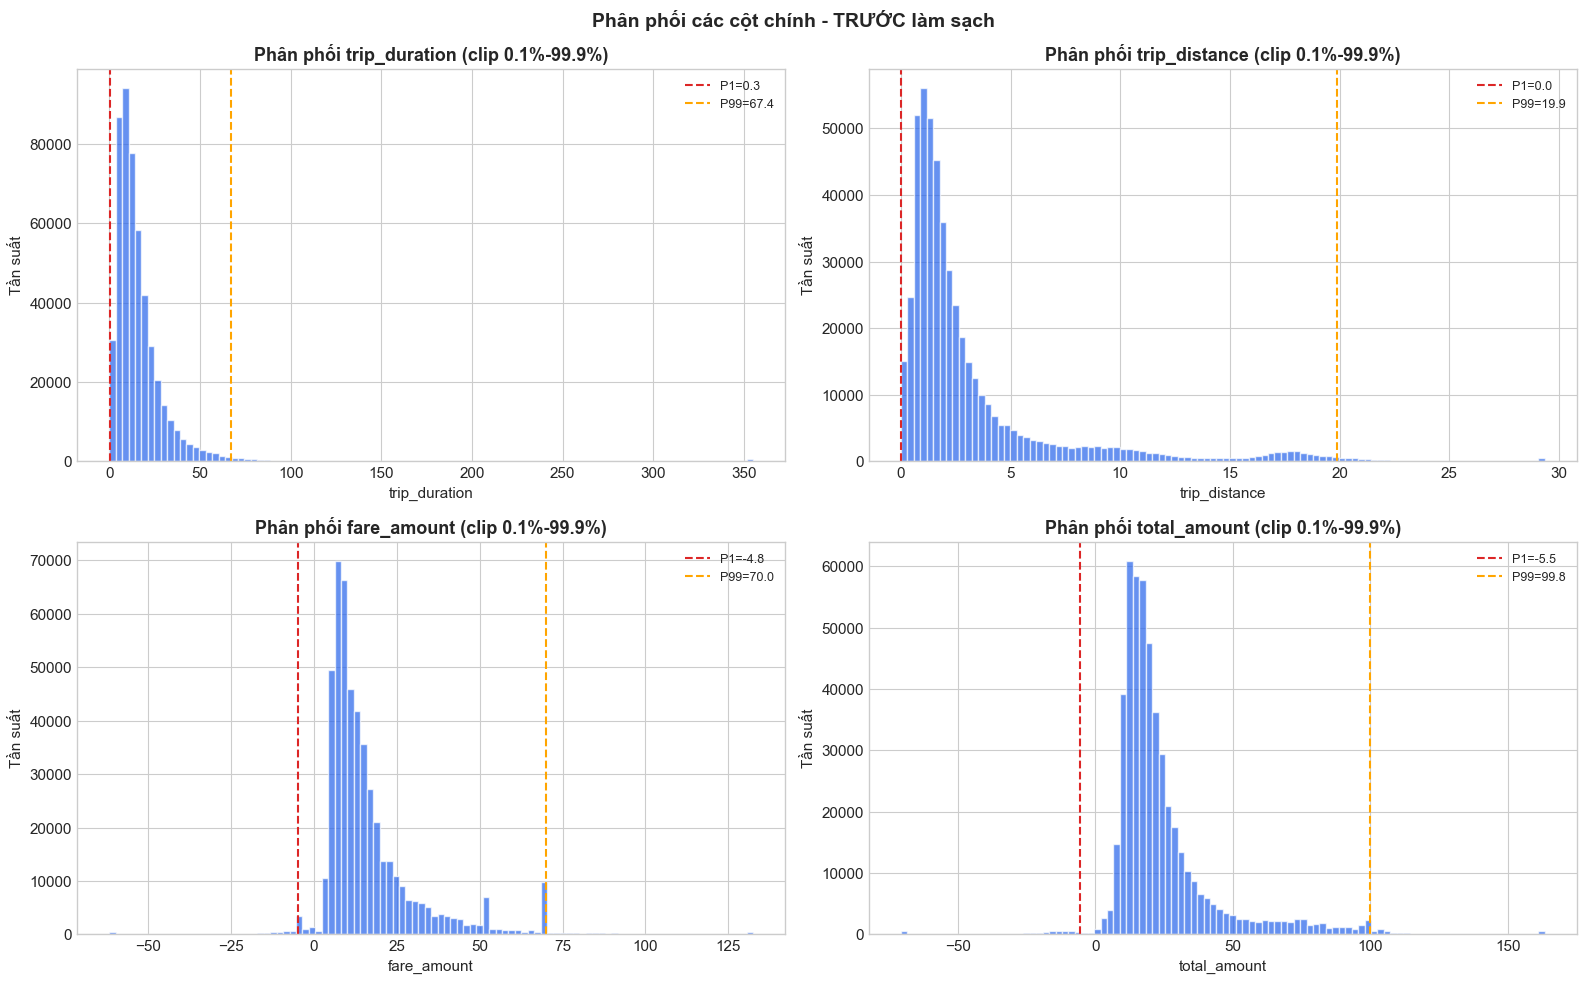

In [11]:
# --- BIỂU ĐỒ PHÂN PHỐI TRƯỚC LÀM SẠCH (HIỂN THỊ OUTLIER) ---
cols_plot = ['trip_duration', 'trip_distance', 'fare_amount', 'total_amount']
cols_plot = [c for c in cols_plot if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    vals = df[col].dropna()
    p01, p99 = vals.quantile(0.01), vals.quantile(0.99)
    print(f'--- SỐ LIỆU: Phân phối {col} (trước làm sạch) ---')
    print(vals.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).round(3).to_string())
    print(f'  P1 = {p01:.2f}, P99 = {p99:.2f}')
    print()
    axes[i].hist(vals.clip(vals.quantile(0.001), vals.quantile(0.999)), bins=100,
                 color=COLOR_PRIMARY, alpha=0.7, edgecolor='white')
    axes[i].axvline(p01, color=COLOR_WARN, linestyle='--', label=f'P1={p01:.1f}')
    axes[i].axvline(p99, color='orange', linestyle='--', label=f'P99={p99:.1f}')
    axes[i].set_title(f'Phân phối {col} (clip 0.1%-99.9%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Tần suất')
    axes[i].legend(fontsize=9)

plt.suptitle('Phân phối các cột chính - TRƯỚC làm sạch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ===================================================
#   LÀM SẠCH DỮ LIỆU
# ===================================================
n_before = len(df)

# Điều kiện lọc
mask_valid = (
    df['tpep_pickup_datetime'].notna() &
    df['tpep_dropoff_datetime'].notna() &
    df['year'].between(2020, 2025) &
    (df['trip_duration'] > 0) &
    (df['trip_duration'] <= 300) &
    (df['trip_distance'] > 0) &
    (df['trip_distance'] <= 150) &
    (df['fare_amount'] > 0) &
    (df['fare_amount'] <= 500) &
    (df['total_amount'] > 0)
)

if 'avg_speed_mph' in df.columns:
    mask_valid &= (df['avg_speed_mph'] <= 80) | df['avg_speed_mph'].isna()
if 'passenger_count' in df.columns:
    mask_valid &= (df['passenger_count'].between(1, 6) | df['passenger_count'].isna())

df_clean = df[mask_valid].copy()
n_after  = len(df_clean)
removed  = n_before - n_after

print('===================================================')
print('   KẾT QUẢ LÀM SẠCH DỮ LIỆU')
print('===================================================')
print(f'  Số dòng trước làm sạch : {n_before:>12,}')
print(f'  Số dòng sau làm sạch   : {n_after:>12,}')
print(f'  Số dòng đã loại bỏ     : {removed:>12,} ({removed/n_before*100:.2f}%)')
print()

# Thống kê sau làm sạch
print('--- THỐNG KÊ MÔ TẢ CÁC CỘT CHÍNH (SAU LÀM SẠCH) ---')
print(df_clean[describe_cols].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).round(3).to_string())

   KẾT QUẢ LÀM SẠCH DỮ LIỆU
  Số dòng trước làm sạch :      499,965
  Số dòng sau làm sạch   :      472,001
  Số dòng đã loại bỏ     :       27,964 (5.59%)

--- THỐNG KÊ MÔ TẢ CÁC CỘT CHÍNH (SAU LÀM SẠCH) ---
       trip_duration  trip_distance  fare_amount   tip_amount  total_amount  avg_speed_mph
count   472,001.0000   472,001.0000 472,001.0000 472,001.0000  472,001.0000   472,001.0000
mean         15.9530         3.4060      17.2710       2.9610       25.1240        11.5900
std          12.9880         4.3240      15.8840       3.7000       20.0080         6.4910
min           0.0170         0.0100       0.0100       0.0000        0.3100         0.0080
1%            1.9500         0.3000       3.7000       0.0000        7.3000         2.7930
5%            3.5830         0.5300       5.0000       0.0000        9.7500         4.5530
25%           7.5500         1.1000       8.0000       0.0000       13.8000         7.4600
50%          12.3670         1.8300      12.1000       2.3000  

--- SỐ LIỆU BIỂU ĐỒ: Số dòng loại bỏ theo lý do ---
  Ngày giờ bị trống: 0 (0.00%)
  Năm ngoài phạm vi: 4 (0.00%)
  Thời gian <= 0: 1,589 (0.32%)
  Thời gian > 300 phút: 509 (0.10%)
  Quãng đường <= 0: 9,648 (1.93%)
  Quãng đường > 150 dặm: 16 (0.00%)
  Giá cước <= 0: 10,145 (2.03%)
  Giá cước > 500: 4 (0.00%)
  Tổng tiền <= 0: 5,592 (1.12%)
  Tốc độ > 80 mph: 390 (0.08%)

--- SỐ LIỆU BIỂU ĐỒ: Tỷ lệ giữ lại / loại bỏ ---
  Giữ lại: 472,001 (94.41%)
  Loại bỏ: 27,964 (5.59%)



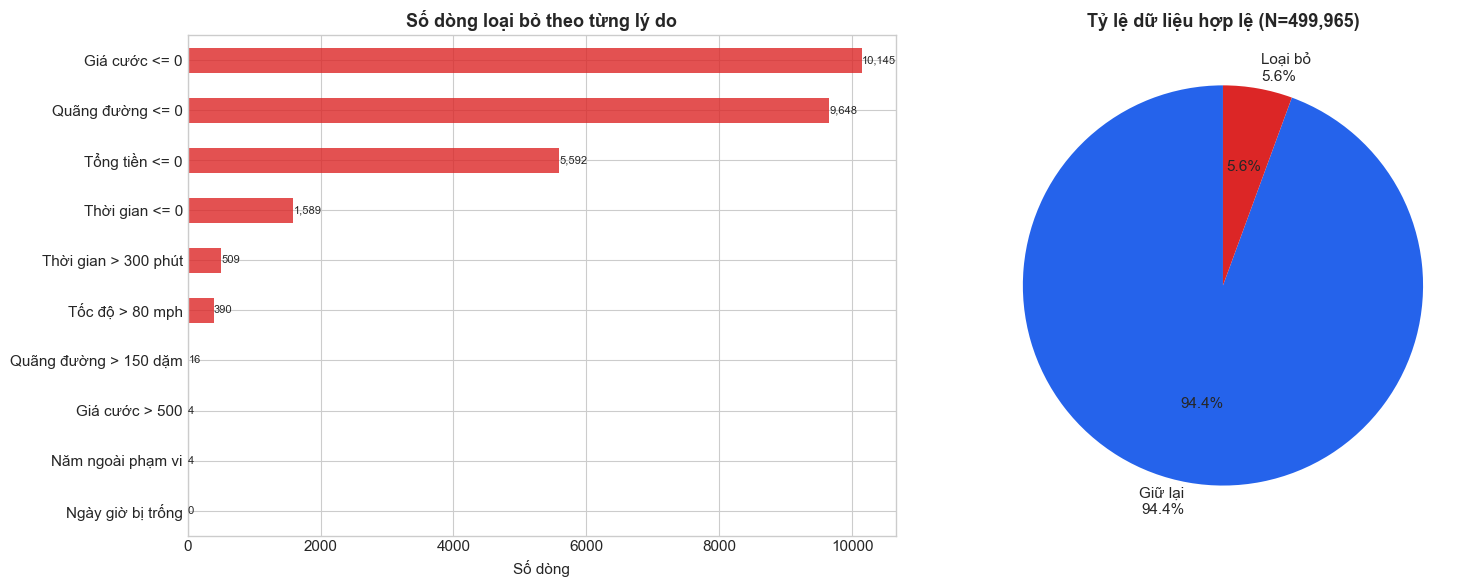

In [13]:
# --- BIỂU ĐỒ SO SÁNH TRƯỚC / SAU LÀM SẠCH ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Số lượng bị loại theo lý do
removal_reasons = {
    'Ngày giờ bị trống': df['tpep_pickup_datetime'].isna().sum(),
    'Năm ngoài phạm vi': (~df['year'].between(2020, 2025)).sum(),
    'Thời gian <= 0': (df['trip_duration'] <= 0).sum(),
    'Thời gian > 300 phút': (df['trip_duration'] > 300).sum(),
    'Quãng đường <= 0': (df['trip_distance'] <= 0).sum(),
    'Quãng đường > 150 dặm': (df['trip_distance'] > 150).sum(),
    'Giá cước <= 0': (df['fare_amount'] <= 0).sum(),
    'Giá cước > 500': (df['fare_amount'] > 500).sum(),
    'Tổng tiền <= 0': (df['total_amount'] <= 0).sum(),
    'Tốc độ > 80 mph': (df['avg_speed_mph'] > 80).sum() if 'avg_speed_mph' in df.columns else 0,
}

print('--- SỐ LIỆU BIỂU ĐỒ: Số dòng loại bỏ theo lý do ---')
for k, v in removal_reasons.items():
    print(f'  {k}: {v:,} ({v/n_before*100:.2f}%)')
print()

r_series = pd.Series(removal_reasons).sort_values(ascending=True)
r_series.plot(kind='barh', ax=axes[0], color=COLOR_WARN, alpha=0.8)
axes[0].set_title('Số dòng loại bỏ theo từng lý do')
axes[0].set_xlabel('Số dòng')
for i, v in enumerate(r_series):
    axes[0].text(v + 5, i, f'{v:,}', va='center', fontsize=8)

# Biểu đồ tròn tỷ lệ giữ lại / loại bỏ
print('--- SỐ LIỆU BIỂU ĐỒ: Tỷ lệ giữ lại / loại bỏ ---')
print(f'  Giữ lại: {n_after:,} ({n_after/n_before*100:.2f}%)')
print(f'  Loại bỏ: {removed:,} ({removed/n_before*100:.2f}%)')
print()
axes[1].pie([n_after, removed],
             labels=[f'Giữ lại\n{n_after/n_before*100:.1f}%', f'Loại bỏ\n{removed/n_before*100:.1f}%'],
             colors=[COLOR_PRIMARY, COLOR_WARN],
             autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Tỷ lệ dữ liệu hợp lệ (N={n_before:,})')

plt.tight_layout()
plt.show()

**Nhan xet 3 - Chất lượng dữ liệu**

* Dữ liệu ban đầu chứa nhiều giá trị phi lý ở các biến quan trọng như thời gian, khoảng cách, giá tiền và tốc độ, nhưng phần lớn có tỷ lệ thấp (<2%), ngoại trừ các lỗi về distance ≤ 0, fare ≤ 0 và passenger_count ≤ 0 (~1–2%).
* Một số outlier cực đoan xuất hiện (distance rất lớn, duration hàng nghìn phút, speed gần 900,000 mph) làm sai lệch mạnh các thống kê như mean và std.
* Các vấn đề nghiêm trọng nhất tập trung ở nhóm giá trị âm hoặc bằng 0 (distance, fare, total), vì vi phạm logic nghiệp vụ.
* Sau khi làm sạch, đã loại bỏ 5.59% dữ liệu, giữ lại ~94.4% → mức mất dữ liệu chấp nhận được.
* Phân phối các biến sau làm sạch trở nên hợp lý hơn: mean giảm về mức thực tế, std giảm mạnh, các giá trị min/max nằm trong ngưỡng hợp lý.
* Tốc độ trung bình giảm từ ~20 mph xuống ~11.6 mph, phản ánh việc loại bỏ các chuyến đi phi thực tế.
* Việc loại bỏ outlier giúp tăng độ tin cậy cho phân tích và mô hình hóa, đặc biệt với các bài toán liên quan đến dự đoán thời gian, chi phí và hành vi di chuyển.


---
## 4. Tương quan giữa các biến

Phân tích sau làm sạch để hiểu tương quan, chuẩn bị cho bài toán Regression.

--- SỐ LIỆU HEATMAP TƯƠNG QUAN (Pearson r) ---
                 trip_distance  trip_duration  fare_amount  tip_amount  tolls_amount  total_amount  avg_speed_mph    hour  day_of_week  passenger_count
trip_distance           1.0000         0.7870       0.9050      0.5220        0.6430        0.8910         0.6860 -0.0180       0.0080           0.0290
trip_duration           0.7870         1.0000       0.8150      0.4530        0.4720        0.7900         0.2310  0.0130      -0.0250           0.0190
fare_amount             0.9050         0.8150       1.0000      0.5570        0.6200        0.9760         0.5310 -0.0050       0.0010           0.0230
tip_amount              0.5220         0.4530       0.5570      1.0000        0.4440        0.6950         0.3170  0.0310      -0.0190           0.0020
tolls_amount            0.6430         0.4720       0.6200      0.4440        1.0000        0.6920         0.4520 -0.0160      -0.0060           0.0240
total_amount            0.8910         0.

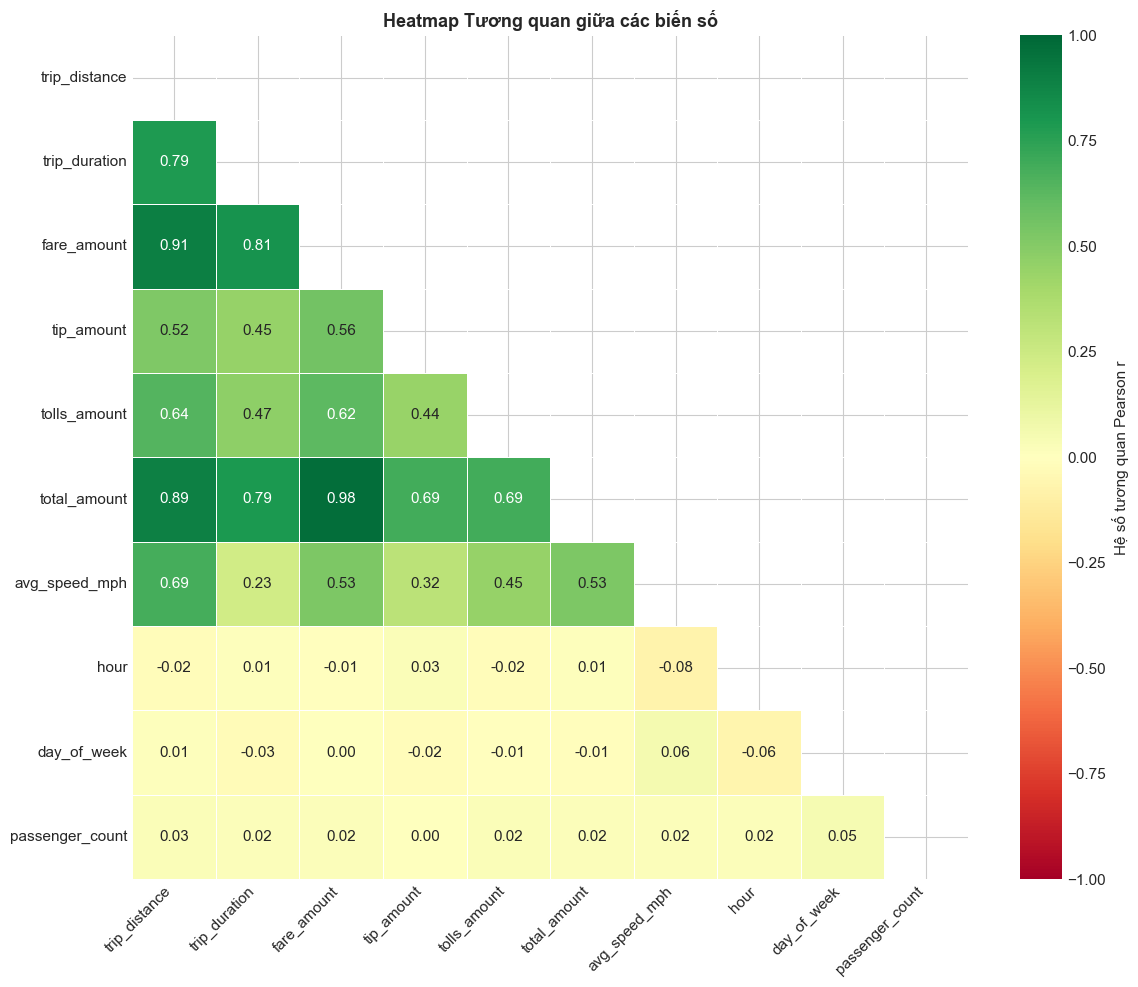

In [14]:
# --- HEATMAP TƯƠNG QUAN ---
corr_cols = ['trip_distance', 'trip_duration', 'fare_amount', 'tip_amount',
             'tolls_amount', 'total_amount', 'avg_speed_mph', 'hour', 'day_of_week']
corr_cols = [c for c in corr_cols if c in df_clean.columns]

if 'passenger_count' in df_clean.columns:
    corr_cols.append('passenger_count')

corr_matrix = df_clean[corr_cols].corr().round(3)

print('--- SỐ LIỆU HEATMAP TƯƠNG QUAN (Pearson r) ---')
print(corr_matrix.to_string())
print()

# Tìm cặp tương quan cao
print('--- CẶP BIẾN CÓ TƯƠNG QUAN CAO (|r| > 0.5) ---')
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, r in corr_pairs:
    print(f'  {a} <-> {b}: r = {r:.3f}')
print()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            mask=mask, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Hệ số tương quan Pearson r'})
ax.set_title('Heatmap Tương quan giữa các biến số')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

--- SỐ LIỆU SCATTER Quãng đường vs Giá tiền: r=0.904 ---
  X (trip_distance): mean=3.43, std=4.35
  Y (fare_amount): mean=17.36, std=16.11

--- SỐ LIỆU SCATTER Thời gian vs Giá tiền: r=0.805 ---
  X (trip_duration): mean=16.05, std=13.06
  Y (fare_amount): mean=17.36, std=16.11

--- SỐ LIỆU SCATTER Quãng đường vs Thời gian: r=0.790 ---
  X (trip_distance): mean=3.43, std=4.35
  Y (trip_duration): mean=16.05, std=13.06



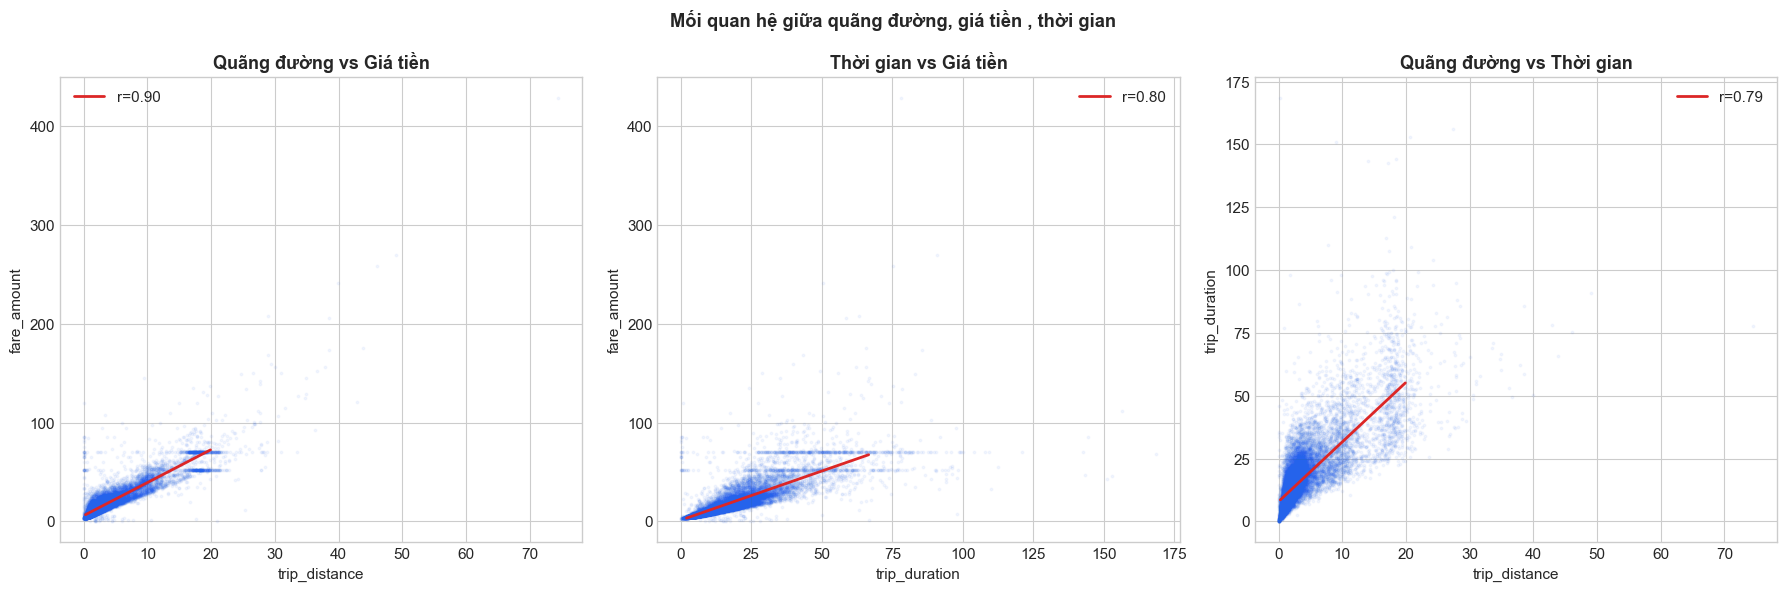

In [15]:
# --- SCATTER PLOT: QUAN DUONG vs GIA TIEN vs THOI GIAN ---
sample_scatter = df_clean.sample(n=min(20000, len(df_clean)), random_state=RANDOM_SEED)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pairs = [
    ('trip_distance', 'fare_amount', 'Quãng đường vs Giá tiền'),
    ('trip_duration', 'fare_amount', 'Thời gian vs Giá tiền'),
    ('trip_distance', 'trip_duration', 'Quãng đường vs Thời gian'),
]

for i, (x_col, y_col, title) in enumerate(pairs):
    if x_col in sample_scatter.columns and y_col in sample_scatter.columns:
        x_data = sample_scatter[x_col]
        y_data = sample_scatter[y_col]
        r = sample_scatter[[x_col, y_col]].corr().iloc[0, 1]
        print(f'--- SỐ LIỆU SCATTER {title}: r={r:.3f} ---')
        print(f'  X ({x_col}): mean={x_data.mean():.2f}, std={x_data.std():.2f}')
        print(f'  Y ({y_col}): mean={y_data.mean():.2f}, std={y_data.std():.2f}')
        print()
        axes[i].scatter(x_data, y_data, alpha=0.05, s=3, color=COLOR_PRIMARY)
        # Duong xu huong
        m, b, *_ = stats.linregress(x_data.dropna(), y_data.dropna())
        x_range = np.linspace(x_data.quantile(0.01), x_data.quantile(0.99), 100)
        axes[i].plot(x_range, m*x_range + b, color=COLOR_WARN, linewidth=2, label=f'r={r:.2f}')
        axes[i].set_title(title)
        axes[i].set_xlabel(x_col)
        axes[i].set_ylabel(y_col)
        axes[i].legend()

plt.suptitle('Mối quan hệ giữa quãng đường, giá tiền , thời gian', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# --- PHÂN TÍCH BIẾN MỤC TIÊU: DEMAND (số chuyến đi theo giờ) ---
df_clean['pickup_date'] = df_clean['tpep_pickup_datetime'].dt.date

demand_hourly = df_clean.groupby(['pickup_date', 'hour']).size().reset_index(name='demand')

print('===================================================')
print('  THỐNG KÊ BIẾN MỤC TIÊU: DEMAND (chuyến/giờ)')
print('===================================================')
print(demand_hourly['demand'].describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99]).round(2).to_string())
print()

skew_val  = demand_hourly['demand'].skew()
kurt_val  = demand_hourly['demand'].kurtosis()
print(f'  Skewness (độ lệch): {skew_val:.3f}')
print(f'  Kurtosis (độ nhọn): {kurt_val:.3f}')

# Shapiro test (trên mẫu nhỏ)
demand_sample = demand_hourly['demand'].sample(min(5000, len(demand_hourly)), random_state=RANDOM_SEED)
_, p_shapiro = stats.shapiro(demand_sample)
_, p_kstest  = stats.kstest(demand_hourly['demand'], 'norm',
    args=(demand_hourly['demand'].mean(), demand_hourly['demand'].std()))
print(f'  Shapiro-Wilk test p-value: {p_shapiro:.4e} ({"Không chuẩn" if p_shapiro < 0.05 else "Chuẩn tắc"} alpha=0.05)')
print(f'  KS test p-value           : {p_kstest:.4e} ({"Không chuẩn" if p_kstest < 0.05 else "Chuẩn tắc"} alpha=0.05)')
print()

# Log transform
demand_log = np.log1p(demand_hourly['demand'])
skew_log   = demand_log.skew()
print(f'  Skewness sau log1p transform: {skew_log:.3f}')
print(f'  => {"Log transform hiệu quả (skew giảm)" if abs(skew_log) < abs(skew_val) else "Log transform không cải thiện"}')

  THỐNG KÊ BIẾN MỤC TIÊU: DEMAND (chuyến/giờ)
count   47,691.0000
mean         9.9000
std          6.6600
min          1.0000
1%           1.0000
5%           1.0000
10%          2.0000
25%          4.0000
50%          9.0000
75%         14.0000
90%         19.0000
95%         21.0000
99%         28.0000
max         50.0000

  Skewness (độ lệch): 0.666
  Kurtosis (độ nhọn): 0.379
  Shapiro-Wilk test p-value: 2.0077e-38 (Không chuẩn alpha=0.05)
  KS test p-value           : 0.0000e+00 (Không chuẩn alpha=0.05)

  Skewness sau log1p transform: -0.574
  => Log transform hiệu quả (skew giảm)


--- SỐ LIỆU BIỂU ĐỒ: Phân phối Demand ---
demand
0-5        14982
5-10       11515
10-20      18167
20-30       2743
30-50        284
50-75          0
75-100         0
100-150        0
150-200        0
>200           0



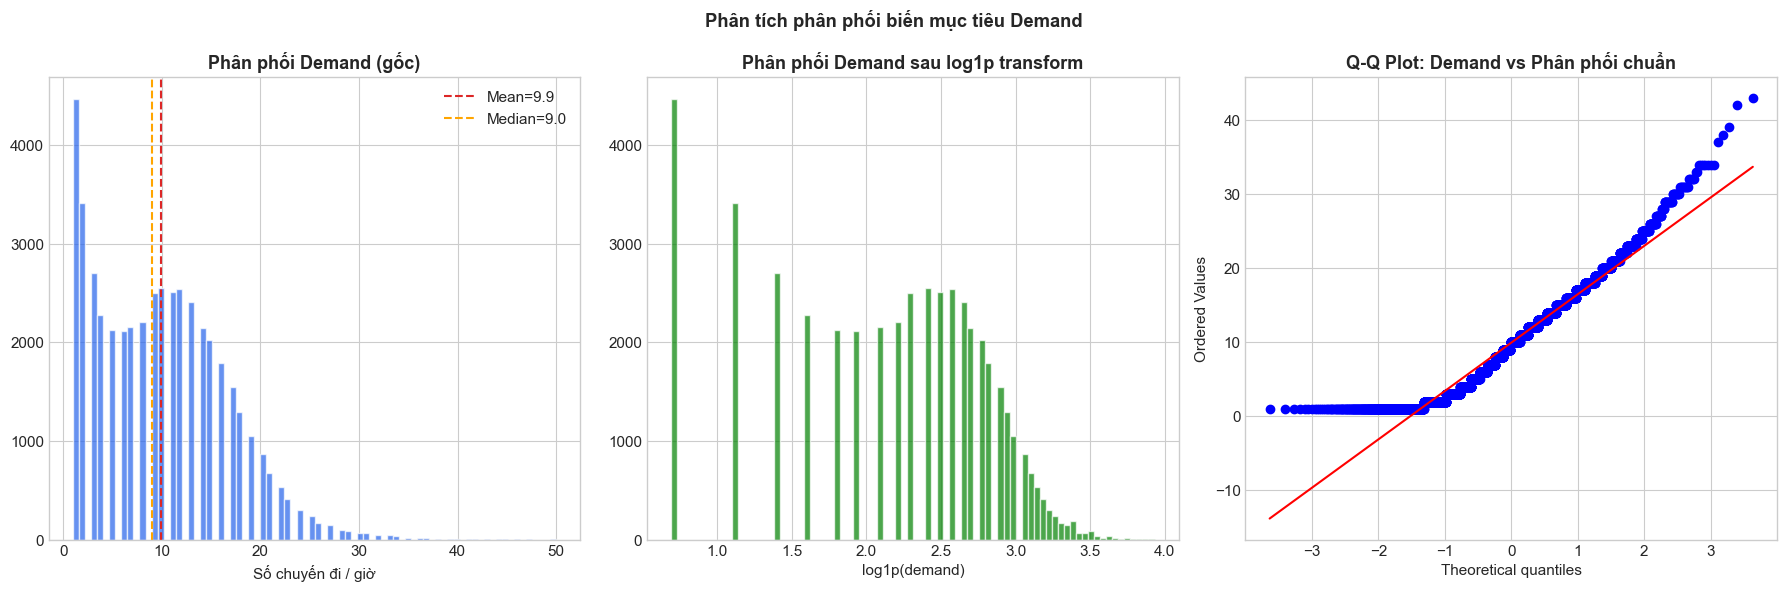

In [17]:
# --- BIỂU ĐỒ PHÂN PHỐI DEMAND ---
print('--- SỐ LIỆU BIỂU ĐỒ: Phân phối Demand ---')
bins_demand = pd.cut(demand_hourly['demand'],
    bins=[0,5,10,20,30,50,75,100,150,200,np.inf],
    labels=['0-5','5-10','10-20','20-30','30-50','50-75','75-100','100-150','150-200','>200'])
print(bins_demand.value_counts().sort_index().to_string())
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Histogram gốc
axes[0].hist(demand_hourly['demand'], bins=80, color=COLOR_PRIMARY, alpha=0.7, edgecolor='white')
axes[0].axvline(demand_hourly['demand'].mean(), color=COLOR_WARN, linestyle='--',
                label=f'Mean={demand_hourly["demand"].mean():.1f}')
axes[0].axvline(demand_hourly['demand'].median(), color='orange', linestyle='--',
                label=f'Median={demand_hourly["demand"].median():.1f}')
axes[0].set_title('Phân phối Demand (gốc)')
axes[0].set_xlabel('Số chuyến đi / giờ')
axes[0].legend()

# Histogram log
axes[1].hist(demand_log, bins=80, color='green', alpha=0.7, edgecolor='white')
axes[1].set_title('Phân phối Demand sau log1p transform')
axes[1].set_xlabel('log1p(demand)')

# Q-Q plot
sample_qq = demand_hourly['demand'].sample(min(5000, len(demand_hourly)), random_state=RANDOM_SEED)
stats.probplot(sample_qq, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot: Demand vs Phân phối chuẩn')

plt.suptitle('Phân tích phân phối biến mục tiêu Demand', fontweight='bold')
plt.tight_layout()
plt.show()

**Nhạn xét 4 - Tương quan và biến mục tiêu**

* Các biến liên quan đến chi phí có tương quan rất mạnh với nhau, đặc biệt `fare_amount` và `total_amount` (r≈0.98), cho thấy trùng lặp thông tin cao → cần tránh đưa đồng thời vào mô hình để hạn chế multicollinearity.
* `trip_distance` là biến ảnh hưởng lớn nhất đến giá tiền (r≈0.91 với fare), tiếp theo là `trip_duration` (r≈0.82) → hai biến này là yếu tố chính quyết định chi phí chuyến đi.
* `tip_amount` và `tolls_amount` có tương quan trung bình với tổng chi phí, phản ánh đóng góp bổ sung nhưng không phải yếu tố cốt lõi.
* `avg_speed_mph` có tương quan vừa phải với distance và fare, nhưng thấp với duration → tốc độ không phải yếu tố trực tiếp quyết định giá.
* Các biến thời gian (`hour`, `day_of_week`) và `passenger_count` gần như không có tương quan tuyến tính đáng kể với các biến còn lại (|r| ≈ 0) → tác động nếu có mang tính phi tuyến hoặc theo pattern.
* Biến mục tiêu demand (số chuyến/giờ) có phân phối lệch phải (skew ≈ 0.67), không tuân theo phân phối chuẩn (p-value ≈ 0).
* Phần lớn giá trị tập trung trong khoảng 5–20 chuyến/giờ, rất ít giá trị cực lớn → dữ liệu có tail nhưng không quá nặng.
* Sau biến đổi log1p, skew chuyển sang âm nhẹ (~ -0.57), cho thấy phân phối trở nên cân đối hơn → phù hợp hơn cho các mô hình hồi quy.
* Kết luận:
  * Nên ưu tiên `trip_distance` và `trip_duration` làm biến giải thích chính cho giá.
  * Tránh dùng đồng thời các biến chi phí có tương quan cao (`fare_amount`, `total_amount`).
  * Áp dụng log transform cho biến demand để cải thiện giả định phân phối và hiệu quả mô hình regression.


---
<a id='3-time'></a>
## 5. Thời gian

--- SỐ LIỆU: Số chuyến đi theo năm-tháng (dữ liệu mẫu) ---
year     2020   2021   2022   2023   2024   2025
month                                           
1      13,821  2,938  5,274  6,584  6,332  7,211
2      13,613  2,913  6,407  6,261  6,411  7,377
3       6,508  4,115  7,779  7,286  7,638  8,539
4         494  4,606  7,756  7,062  7,570  8,150
5         729  5,359  7,690  7,576  7,991  9,104
6       1,149  6,071  7,637  7,116  7,611  8,598
7       1,668  6,060  6,771  6,227  6,574  7,812
8       2,130  5,946  6,732  6,031  6,312  7,057
9       2,861  6,328  6,837  5,997  7,725  8,577
10      3,575  7,433  7,882  7,404  8,140  8,721
11      3,234  7,461  6,968  7,085  7,793  8,112
12      3,127  6,902  7,266  7,211  7,754  9,012

--- TĂNG TRƯỞNG YoY ---
  2020: N/A (năm đầu)
  2021: +25.0%
  2022: +28.5%
  2023: -3.7%
  2024: +7.3%
  2025: +11.9%



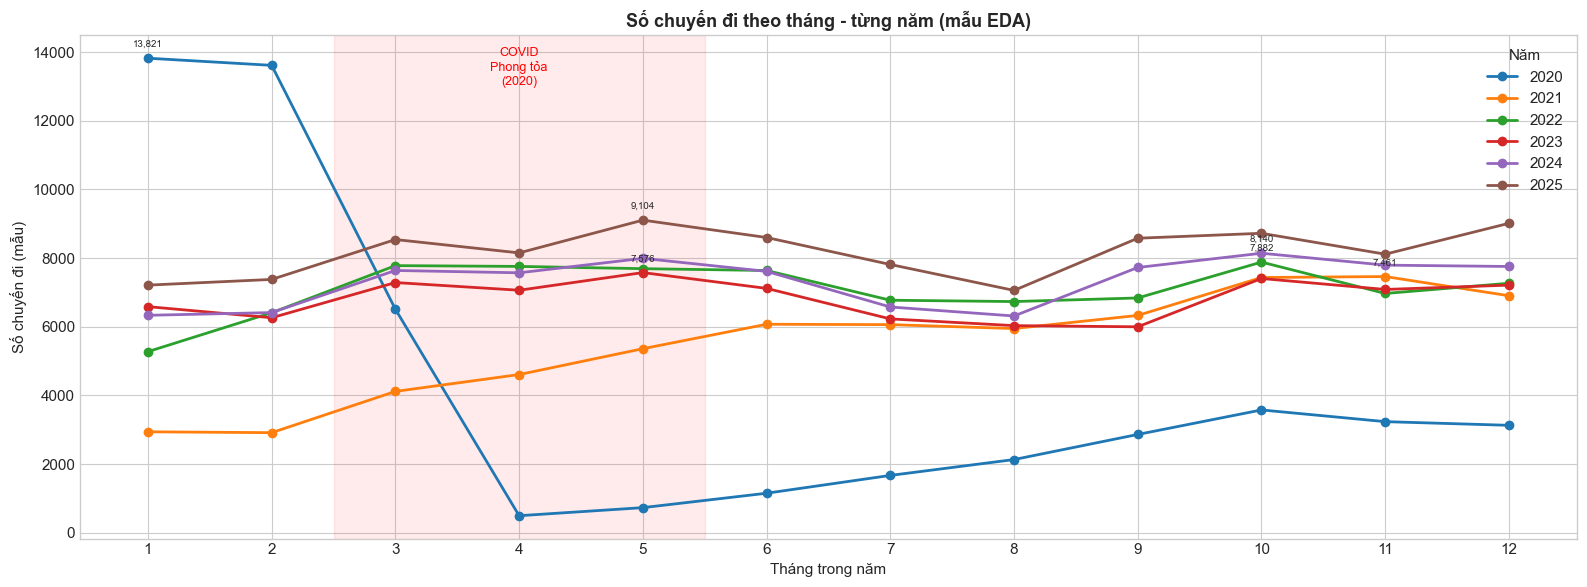

In [18]:
# --- THỐNG KÊ SỐ CHUYẾN ĐI THEO NĂM-THÁNG TỪ DỮ LIỆU MẪU ---
monthly_trips = df_clean.groupby(['year', 'month']).size().reset_index(name='trip_count')
monthly_trips['year_month'] = monthly_trips['year'].astype(str) + '-' + monthly_trips['month'].apply(lambda x: f'{x:02d}')
monthly_trips = monthly_trips.sort_values('year_month')

print('--- SỐ LIỆU: Số chuyến đi theo năm-tháng (dữ liệu mẫu) ---')
pivot_monthly = monthly_trips.pivot(index='month', columns='year', values='trip_count')
print(pivot_monthly.map(lambda x: '{:,.0f}'.format(x) if pd.notna(x) else 'N/A').to_string())
print()

# Tăng trưởng YoY
yearly_total = monthly_trips.groupby('year')['trip_count'].sum()
yoy = yearly_total.pct_change() * 100
print('--- TĂNG TRƯỞNG YoY ---')
for y, v in yoy.items():
    sign = '+' if v > 0 else ''
    print(f'  {y}: {sign}{v:.1f}%' if not pd.isna(v) else f'  {y}: N/A (năm đầu)')
print()

fig, ax = plt.subplots(figsize=(16, 6))
for year in sorted(monthly_trips['year'].unique()):
    sub = monthly_trips[monthly_trips['year'] == year].sort_values('month')
    ax.plot(sub['month'], sub['trip_count'], marker='o', linewidth=2, label=str(year))
    # Nhãn giá trị tại đỉnh/đáy
    peak_month = sub.loc[sub['trip_count'].idxmax(), 'month']
    peak_val   = sub['trip_count'].max()
    ax.annotate(f'{peak_val:,.0f}', xy=(peak_month, peak_val),
                xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7)

ax.axvspan(2.5, 5.5, alpha=0.08, color='red')
ax.text(4, ax.get_ylim()[1]*0.9, 'COVID\nPhong tỏa\n(2020)', ha='center', color='red', fontsize=9)
ax.set_title('Số chuyến đi theo tháng - từng năm (mẫu EDA)')
ax.set_xlabel('Tháng trong năm')
ax.set_ylabel('Số chuyến đi (mẫu)')
ax.set_xticks(range(1, 13))
ax.legend(title='Năm')
plt.tight_layout()
plt.show()

--- SỐ LIỆU BIỂU ĐỒ: Số chuyến đi trung bình/ngày theo giờ ---
year   2020    2021    2022    2023    2024    2025
hour                                               
0    3.1000  4.0000  6.5500  6.2500  7.1000  8.4000
1    2.1800  2.5200  4.4200  4.2800  4.5200  5.5400
2    1.4600  1.8000  2.8700  2.7100  2.7900  3.5800
3    1.1000  1.0300  1.9400  1.8300  2.0400  2.6100
4    0.9900  0.7800  1.2900  1.1700  1.4500  1.7900
5    1.1100  1.0400  1.4200  1.3200  1.4400  2.0800
6    3.0300  2.8700  3.5700  2.9800  3.3700  4.4600
7    5.2900  5.2200  6.7500  6.2500  6.5900  7.8500
8    7.0600  7.2500  8.6500  8.3500  9.3100 10.4600
9    6.9300  8.1600 10.1200  9.5900 10.0900 11.3100
10   7.3300  9.4500 11.1200 10.6000 10.6400 11.5000
11   7.7600 10.0600 12.0500 11.3600 11.8600 12.6800
12   8.3100 11.0600 12.9500 12.2800 13.0500 14.1400
13   8.6400 11.1600 13.3400 12.6400 12.9900 14.4300
14   9.3000 11.9400 14.4200 13.4300 14.1800 15.9200
15   9.5600 12.5600 14.5000 13.5900 14.7700 16.3200
1

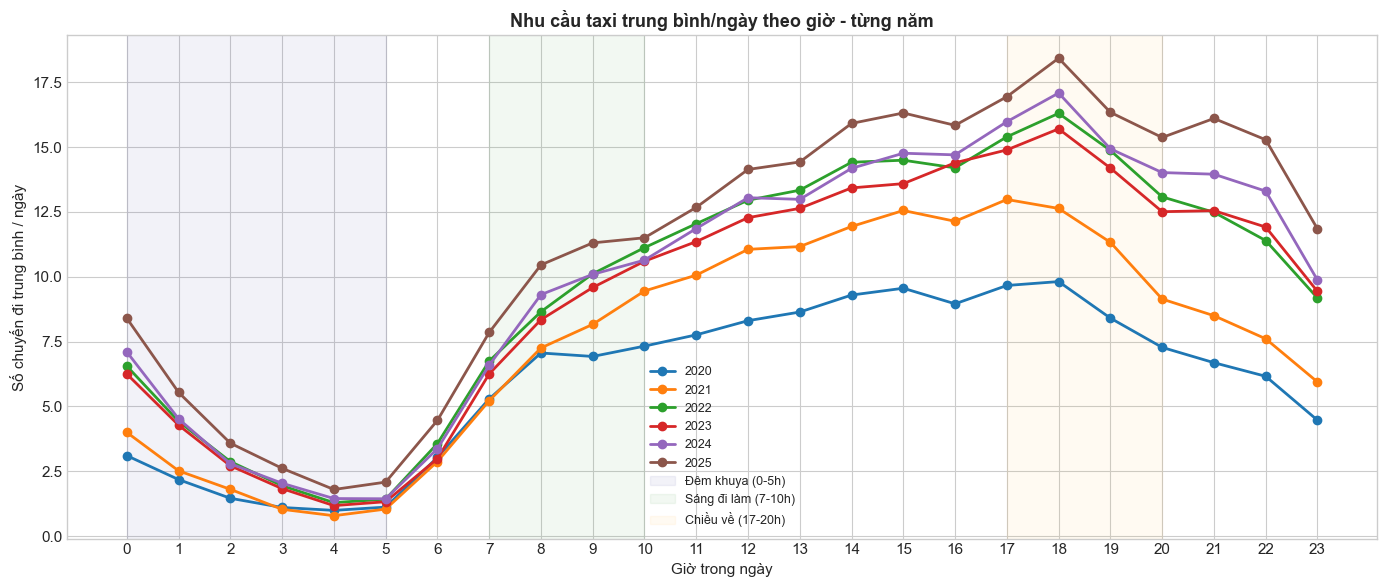

In [19]:
# --- CHU KỲ THEO GIỜ TRONG NGÀY ---
hourly_by_year = df_clean.groupby(['year', 'hour']).size().reset_index(name='count')
# Chuẩn hóa bằng số ngày để so sánh giữa các năm
days_per_year  = df_clean.groupby('year')['pickup_date'].nunique()
hourly_by_year['count_per_day'] = hourly_by_year.apply(
    lambda row: row['count'] / days_per_year.get(row['year'], 1), axis=1
)

print('--- SỐ LIỆU BIỂU ĐỒ: Số chuyến đi trung bình/ngày theo giờ ---')
pivot_hourly = hourly_by_year.pivot(index='hour', columns='year', values='count_per_day').round(2)
print(pivot_hourly.to_string())
print()

# Cao điểm theo giờ
overall_hourly = df_clean.groupby('hour').size()
print('--- TOP 5 GIỜ CAO ĐIỂM VÀ THẤP ĐIỂM ---')
print('  Top 5 cao điểm:')
print(overall_hourly.nlargest(5).to_string())
print('  Top 5 thấp điểm:')
print(overall_hourly.nsmallest(5).to_string())
print()

fig, ax = plt.subplots(figsize=(14, 6))
for year in sorted(hourly_by_year['year'].unique()):
    sub = hourly_by_year[hourly_by_year['year'] == year].sort_values('hour')
    ax.plot(sub['hour'], sub['count_per_day'], marker='o', linewidth=2, label=str(year))

ax.axvspan(0, 5, alpha=0.05, color='navy', label='Đêm khuya (0-5h)')
ax.axvspan(7, 10, alpha=0.05, color='green', label='Sáng đi làm (7-10h)')
ax.axvspan(17, 20, alpha=0.05, color='orange', label='Chiều về (17-20h)')
ax.set_title('Nhu cầu taxi trung bình/ngày theo giờ - từng năm')
ax.set_xlabel('Giờ trong ngày')
ax.set_ylabel('Số chuyến đi trung bình / ngày')
ax.set_xticks(range(24))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

--- SỐ LIỆU BIỂU ĐỒ: Số chuyến đi theo thứ trong tuần ---
year        2020    2021    2022    2023    2024    2025
day_name                                                
Monday     6,889   8,668  10,808  10,233  10,935  11,966
Tuesday    7,708   9,652  12,298  11,781  12,775  13,573
Wednesday  8,301  10,048  12,748  12,587  13,046  14,663
Thursday   8,470  10,257  13,295  12,825  13,603  15,086
Friday     8,338  10,332  13,083  12,191  13,042  14,484
Saturday   7,194   9,557  12,574  11,842  13,310  15,281
Sunday     6,009   7,618  10,193  10,381  11,140  13,217

--- TỶ LỆ NGÀY TRONG TUẦN vs CUỐI TUẦN ---
      Ngày trong tuần  Cuối tuần  Weekend_pct
year                                         
2020            39706      13203      24.9500
2021            48957      17175      25.9700
2022            62232      22767      26.7900
2023            59617      22223      27.1500
2024            63401      24450      27.8300
2025            69772      28498      29.0000



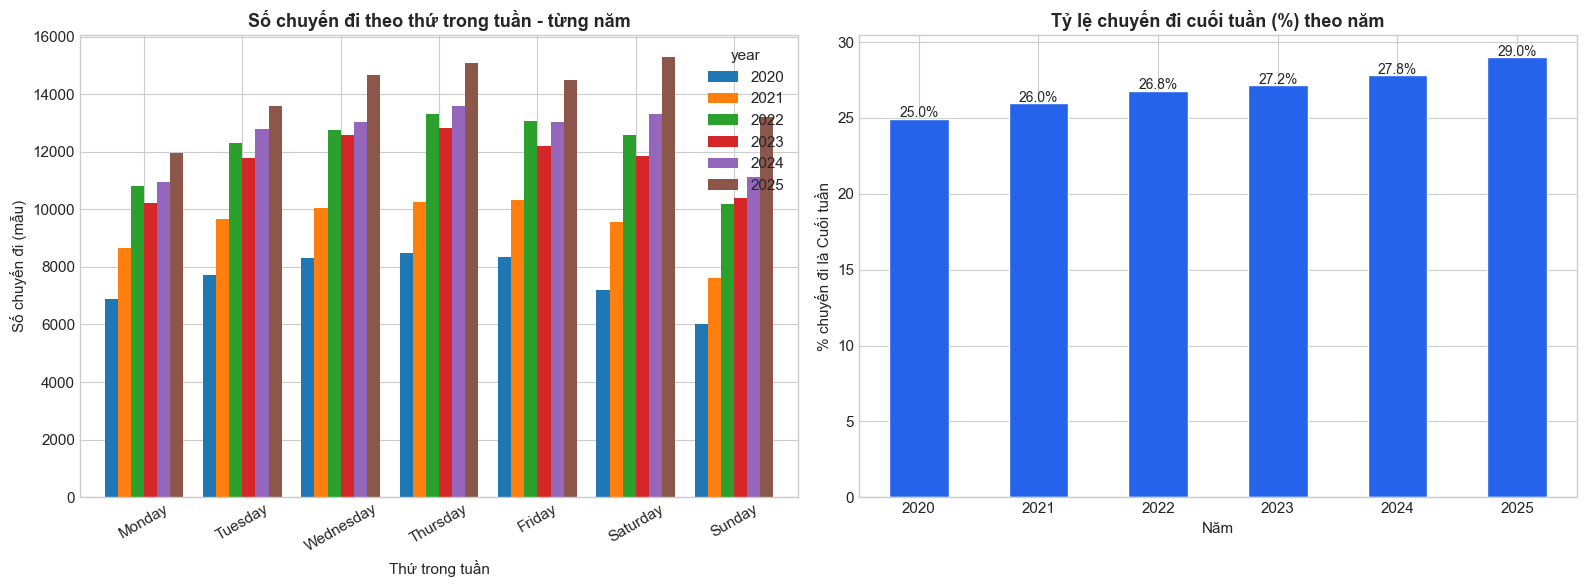

In [20]:
# --- CHU KỲ THEO THỨ TRONG TUẦN ---
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_by_year = df_clean.groupby(['year', 'day_name']).size().reset_index(name='count')

print('--- SỐ LIỆU BIỂU ĐỒ: Số chuyến đi theo thứ trong tuần ---')
pivot_dow = dow_by_year.pivot(index='day_name', columns='year', values='count')
pivot_dow = pivot_dow.reindex(DOW_ORDER)
print(pivot_dow.map(lambda x: '{:,.0f}'.format(x) if pd.notna(x) else 'N/A').to_string())
print()

# Ngày trong tuần vs Cuối tuần
wk_ratio = df_clean.groupby(['year', 'is_weekend']).size().unstack(fill_value=0)
wk_ratio.columns = ['Ngày trong tuần', 'Cuối tuần']
wk_ratio['Weekend_pct'] = wk_ratio['Cuối tuần'] / (wk_ratio['Ngày trong tuần'] + wk_ratio['Cuối tuần']) * 100
print('--- TỶ LỆ NGÀY TRONG TUẦN vs CUỐI TUẦN ---')
print(wk_ratio.round(2).to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ cột nhóm
pivot_dow.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Số chuyến đi theo thứ trong tuần - từng năm')
axes[0].set_xlabel('Thứ trong tuần')
axes[0].set_ylabel('Số chuyến đi (mẫu)')
axes[0].tick_params(axis='x', rotation=30)

# Tỷ lệ cuối tuần qua các năm
wk_ratio['Weekend_pct'].plot(kind='bar', ax=axes[1], color=COLOR_PRIMARY, edgecolor='white')
for i, v in enumerate(wk_ratio['Weekend_pct']):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10)
axes[1].set_title('Tỷ lệ chuyến đi cuối tuần (%) theo năm')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('% chuyến đi là Cuối tuần')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

--- SỐ LIỆU HEATMAP: Số chuyến đi theo giờ x thứ ---
hour        0     1     2     3    4    5     6     7     8     9     10    11    12    13    14    15    16    17    18    19    20    21    22    23
Thứ 2      998   491   288   209  248  466  1200  2222  2872  2941  3137  3238  3548  3580  3894  4134  4066  4175  4136  3551  3193  2954  2406  1552
Thứ 3      875   405   216   156  191  417  1238  2459  3457  3444  3400  3610  3770  3787  4195  4324  4290  4734  4962  4293  3971  4007  3417  2169
Thứ 4     1153   572   309   212  233  509  1298  2577  3417  3448  3510  3642  3988  3944  4359  4391  4322  4949  5250  4473  4162  4421  3722  2532
Thứ 5     1399   625   350   260  253  469  1292  2618  3341  3614  3526  3609  3977  4045  4447  4545  4364  4747  5424  4755  4382  4359  4090  3045
Thứ 6     2000  1183   690   410  344  480  1203  2173  2923  2994  3154  3486  3738  3838  4243  4471  4327  4691  5003  4688  3933  3789  3989  3720
Thứ 7     3237  2556  1805  1226  672  34

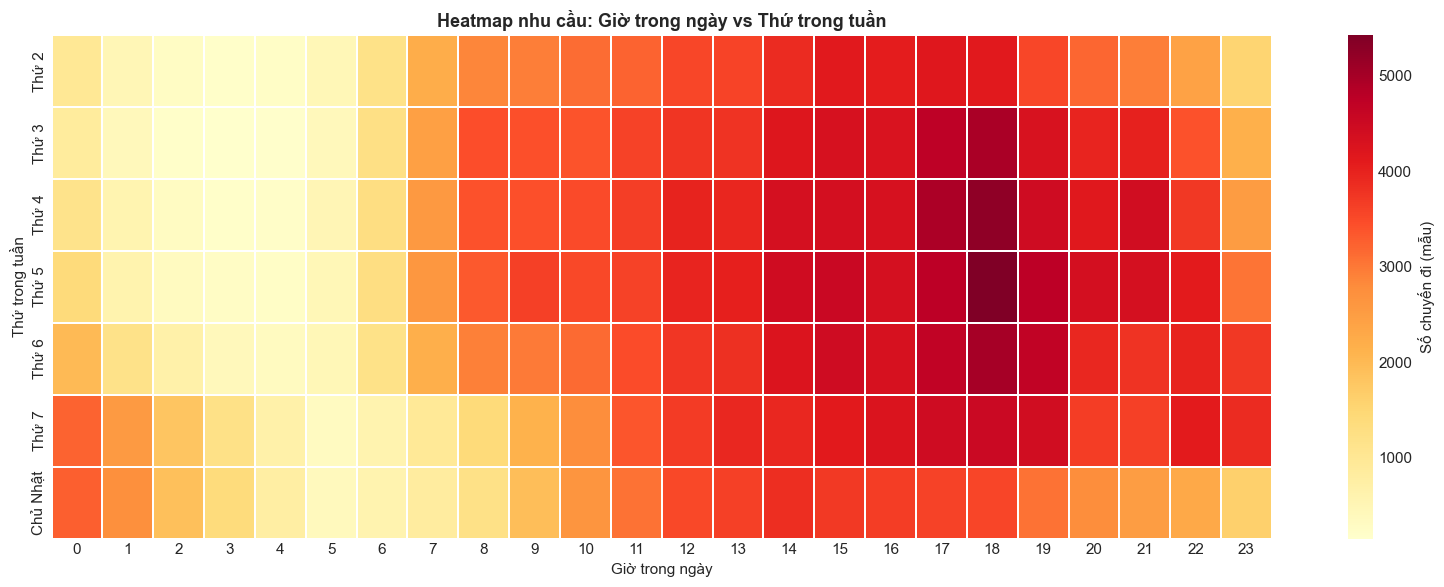

In [21]:
# --- HEATMAP: GIỜ vs THỨ TRONG TUẦN ---
heat_data = df_clean.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
heat_data.index = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật']

print('--- SỐ LIỆU HEATMAP: Số chuyến đi theo giờ x thứ ---')
print(heat_data.to_string())
print()

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heat_data, cmap='YlOrRd', annot=False, fmt='d',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Số chuyến đi (mẫu)'})
ax.set_title('Heatmap nhu cầu: Giờ trong ngày vs Thứ trong tuần')
ax.set_xlabel('Giờ trong ngày')
ax.set_ylabel('Thứ trong tuần')
plt.tight_layout()
plt.show()

--- SỐ LIỆU: Số chuyến đi theo tháng-năm (toàn bộ dataset) ---
year        2020       2021       2022       2023       2024       2025
month                                                                  
1      6,405,008  1,369,769  2,463,931  3,066,766  2,964,624  3,475,226
2      6,299,367  1,371,709  2,979,431  2,913,955  3,007,526  3,577,543
3      3,007,687  1,925,152  3,627,882  3,403,766  3,582,628  4,145,257
4        238,073  2,171,187  3,599,920  3,288,250  3,514,289  3,970,553
5        348,415  2,507,109  3,588,295  3,513,649  3,723,833  4,591,845
6        549,797  2,834,264  3,558,124  3,307,234  3,539,193  4,322,960
7        800,412  2,821,746  3,174,394  2,907,108  3,076,903  3,898,963
8      1,007,286  2,788,757  3,152,677  2,824,209  2,979,183  3,574,091
9      1,341,017  2,963,793  3,183,767  2,846,722  3,633,030  4,251,015
10     1,681,132  3,463,504  3,675,411  3,522,285  3,833,771  4,428,699
11     1,509,000  3,472,949  3,252,717  3,339,715  3,646,369  4,181,444
1

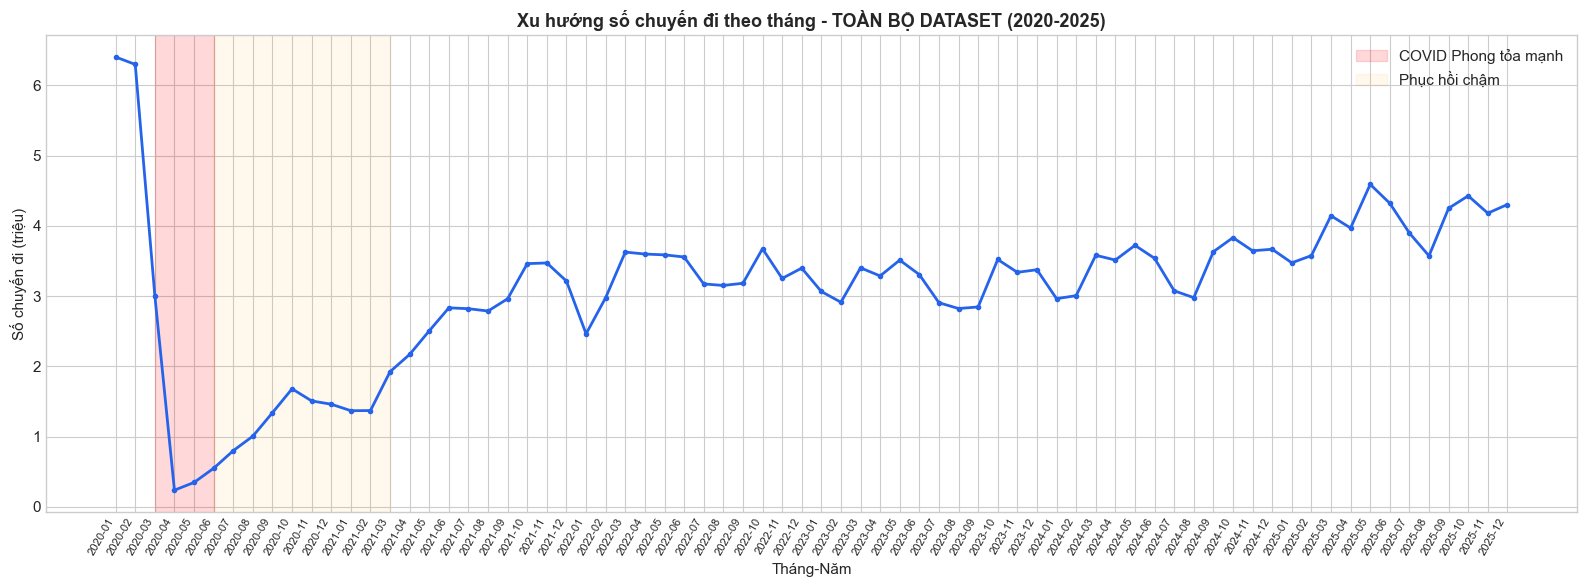

In [22]:
# --- PHÂN TÍCH BIẾN ĐỘNG COVID: SO SÁNH 2019 vs 2020 vs 2021 ---
# Sử dụng dữ liệu tổng hợp từ df_files (số thật)
monthly_raw = df_files.groupby(['year', 'month'])['row_count'].sum().reset_index()

# Chuẩn hóa về % so với tháng cùng kỳ 2019 (nếu có)
pre_covid_ref = monthly_raw[monthly_raw['year'] == 2019].set_index('month')['row_count'] if 2019 in monthly_raw['year'].values else None

print('--- SỐ LIỆU: Số chuyến đi theo tháng-năm (toàn bộ dataset) ---')
pivot_full = monthly_raw.pivot(index='month', columns='year', values='row_count')
print(pivot_full.map(lambda x: '{:,.0f}'.format(x) if pd.notna(x) else 'N/A').to_string())
print()

# % thay đổi so với cùng tháng năm trước
for year in sorted(monthly_raw['year'].unique()):
    if year == monthly_raw['year'].min():
        continue
    cur  = monthly_raw[monthly_raw['year'] == year].set_index('month')['row_count']
    prev = monthly_raw[monthly_raw['year'] == year - 1].set_index('month')['row_count']
    change = ((cur - prev) / prev * 100).dropna()
    print(f'  % thay đổi so với {year-1} -> {year}:')
    for m, v in change.items():
        print(f'    Tháng {m:02d}: {"+" if v > 0 else ""}{v:.1f}%')
    print()

# Biểu đồ đường xu hướng toàn bộ
fig, ax = plt.subplots(figsize=(16, 6))
monthly_raw['period'] = monthly_raw['year'].astype(str) + '-' + monthly_raw['month'].apply(lambda x: f'{x:02d}')
monthly_raw_sorted = monthly_raw.sort_values('period')
ax.plot(monthly_raw_sorted['period'], monthly_raw_sorted['row_count'] / 1e6,
        color=COLOR_PRIMARY, linewidth=2, marker='.')
ax.axvspan('2020-03', '2020-06', alpha=0.15, color='red', label='COVID Phong tỏa mạnh')
ax.axvspan('2020-06', '2021-03', alpha=0.07, color='orange', label='Phục hồi chậm')
ax.set_title('Xu hướng số chuyến đi theo tháng - TOÀN BỘ DATASET (2020-2025)')
ax.set_xlabel('Tháng-Năm')
ax.set_ylabel('Số chuyến đi (triệu)')
plt.xticks(rotation=60, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

**Nhận xét 5 - Thời gian**

* Nhu cầu có chu kỳ rõ rệt theo giờ trong ngày: thấp nhất rạng sáng (2h–5h), tăng mạnh từ 7h–9h (giờ đi làm), đạt đỉnh vào chiều tối (17h–19h), sau đó giảm dần ban đêm.
* Hai khung cao điểm chính: sáng và đặc biệt là chiều tối, trong đó 17h–18h là peak mạnh nhất → phản ánh hành vi đi làm và tan ca.
* Theo tuần, nhu cầu tập trung nhiều vào ngày trong tuần (weekday ~70–75%), nhưng tỷ trọng cuối tuần tăng dần qua các năm (từ ~25% lên ~29%) → xu hướng dịch chuyển sang hoạt động giải trí, du lịch.
* Các ngày giữa tuần (Tue–Thu) có nhu cầu cao nhất, trong khi Chủ nhật thấp hơn do ít hoạt động kinh tế.
* Theo tháng và năm, có biến động lớn giai đoạn 2020–2021:
  * Giảm mạnh đầu 2021 so với 2020 (đặc biệt tháng 1–2: ~-78%) do tác động COVID.
  * Sau đó phục hồi nhanh từ giữa 2021 trở đi, với mức tăng trưởng cao trong 2022.
* Giai đoạn 2023 có dấu hiệu chững lại nhẹ (YoY âm), nhưng từ 2024–2025 nhu cầu tăng ổn định trở lại.
* Năm 2025 cho thấy tăng trưởng mạnh và đồng đều tất cả các tháng (~15–25%) → dấu hiệu phục hồi hoàn toàn và mở rộng nhu cầu.
* Kết luận:
  * Có seasonality rõ theo giờ và theo tuần → cần đưa vào mô hình (feature time-based).
  * Dữ liệu chịu ảnh hưởng mạnh bởi COVID (structural break 2020–2021) → cần xử lý khi modeling chuỗi thời gian.
  * Xu hướng dài hạn là phục hồi và tăng trưởng ổn định sau 2022.


---
<a id='4-spatial'></a>
## 6. Không gian: Điểm nóng, luồng di chuyển

In [23]:
# --- MAPPING ZONE ID VỀ BOROUGH ---
# Định nghĩa thủ công các ID vùng thuộc từng quận chính (theo TLC Zone Lookup)
# Nguồn: https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv

BOROUGH_ZONES = {
    'Manhattan'   : list(range(1, 70))   + [103, 104, 105, 106, 107, 113, 114, 116, 120,
                                            125, 127, 128, 137, 140, 141, 142, 143, 144,
                                            148, 151, 152, 153, 158, 161, 162, 163, 164,
                                            166, 170, 186, 194, 202, 209, 211, 224, 229,
                                            230, 231, 232, 233, 234, 236, 237, 238, 239,
                                            243, 244, 246, 249, 261, 262],
    'Brooklyn'    : list(range(11, 30))  + [14, 17, 21, 22, 25, 26, 29, 33, 34, 35, 36,
                                            37, 39, 40, 52, 54, 55, 61, 62, 63, 77, 80,
                                            85, 111, 112, 123, 133, 149, 150, 154, 155,
                                            165, 172, 173, 174, 176, 178, 181, 188, 189,
                                            190, 195, 210, 217, 222, 225, 227, 228, 255,
                                            256, 257, 258],
    'Queens'      : list(range(70, 103)) + [29, 53, 56, 64, 65, 70, 71, 72, 73, 74, 75,
                                            76, 78, 82, 83, 86, 87, 88, 90, 92, 94, 95,
                                            96, 98, 101, 108, 117, 119, 121, 122, 124,
                                            129, 130, 131, 132, 134, 135, 138, 139, 145,
                                            146, 157, 160, 169, 171, 175, 179, 180, 191,
                                            192, 193, 196, 197, 198, 201, 203, 205, 207,
                                            215, 216, 218, 219, 223, 226, 252, 253, 259,
                                            260, 263],
    'Bronx'       : list(range(3, 13))   + [3, 18, 20, 31, 32, 46, 47, 51, 58, 59, 60,
                                            67, 68, 69, 78, 81, 93, 100, 136, 167, 168,
                                            169, 177, 182, 183, 184, 185, 199, 200, 208,
                                            212, 213, 220, 235, 240, 241, 242, 247, 248,
                                            250, 254],
    'Staten Island': [5, 6, 23, 44, 84, 99, 109, 110, 115, 118, 156, 172, 187, 204,
                      206, 214, 221, 245, 251],
    'EWR/Airport' : [1, 132, 138],
}

def zone_to_borough(zone_id):
    try:
        zone_id = int(zone_id)
    except:
        return 'Unknown'
    for borough, zones in BOROUGH_ZONES.items():
        if zone_id in zones:
            return borough
    return 'Unknown'

if 'PULocationID' in df_clean.columns:
    df_clean['pickup_borough']  = df_clean['PULocationID'].apply(zone_to_borough)
    df_clean['dropoff_borough'] = df_clean['DOLocationID'].apply(zone_to_borough)
    print('Mapping Zone -> Borough hoàn tất.')
    print('Phân bổ pickup theo Borough:')
    print(df_clean['pickup_borough'].value_counts().to_string())
else:
    print('Không tìm thấy cột PULocationID / DOLocationID trong dữ liệu mẫu.')

Mapping Zone -> Borough hoàn tất.
Phân bổ pickup theo Borough:
pickup_borough
Manhattan        378446
Queens            86359
Unknown            3342
Brooklyn           2769
Bronx              1074
Staten Island        11


--- TOP 20 KHU VỰC ĐÓN KHÁCH (Pickup) ---
PULocationID
237    22554
161    20111
132    19948
236    19825
186    15845
162    15650
142    14730
230    14438
170    13972
138    13390
239    13106
163    12922
48     12759
234    12506
68     12034
141    11708
79     11679
164    10404
107    10353
249    10102

--- TOP 20 KHU VỰC TRẢ KHÁCH (Dropoff) ---
DOLocationID
236    21063
237    19968
161    17059
170    14097
230    13357
239    12936
162    12877
142    12832
141    12558
48     11711
68     11505
234    11360
163    11068
238    10732
186    10249
79      9826
229     9822
263     9798
140     9785
164     9698



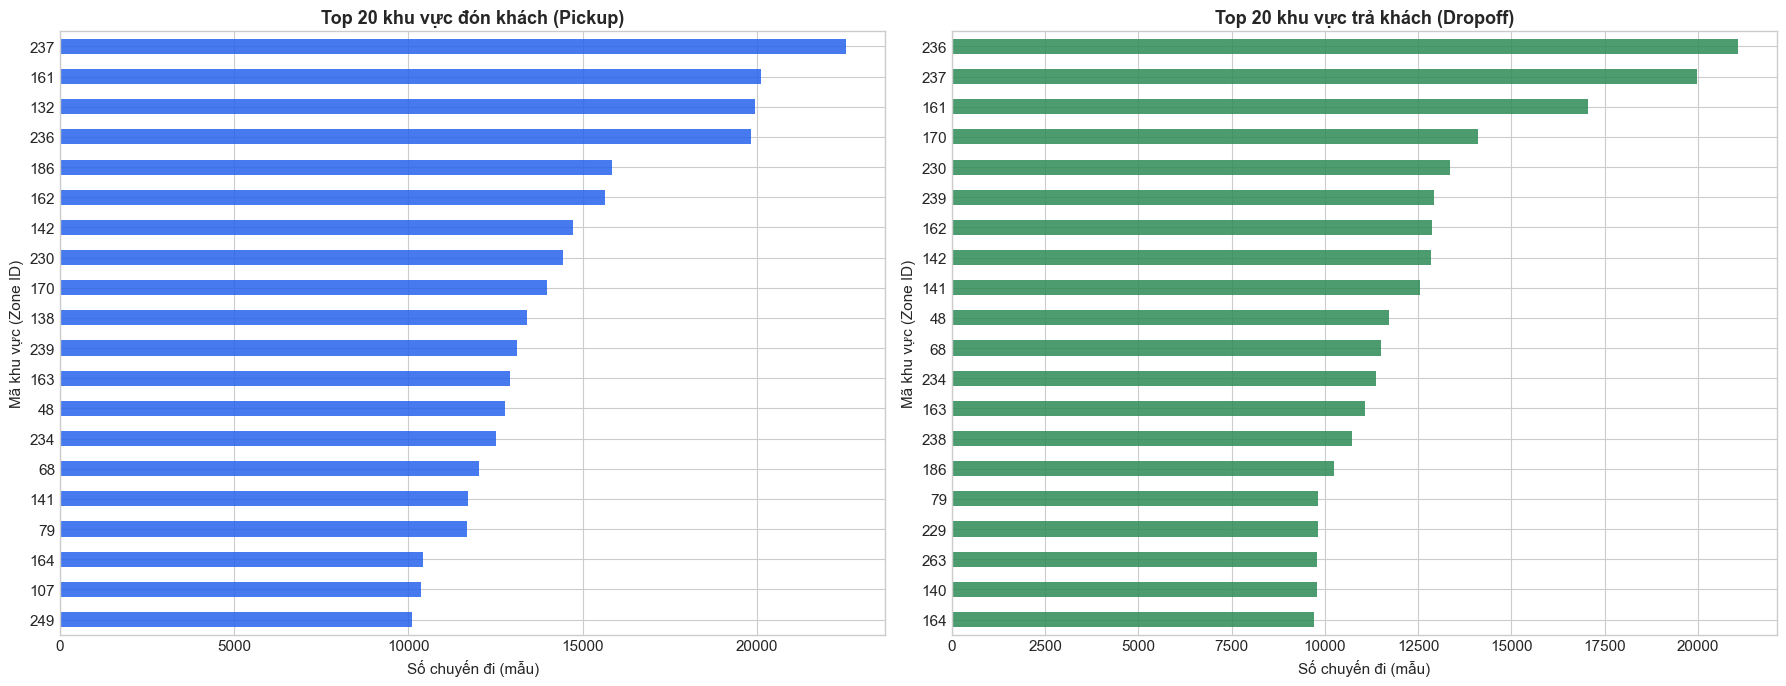

--- TOP 5 KHU VỰC ĐÓN KHÁCH THEO TỪNG NĂM ---
      zone_id  count
year                
2020      237   2456
2020      236   2292
2020      161   1971
2020      186   1950
2020      162   1780
2021      237   3397
2021      236   3018
2021      161   2401
2021      186   2170
2021      170   2137
2022      237   4154
2022      132   3944
2022      236   3534
2022      161   3406
2022      142   2776
2023      132   4332
2023      161   3903
2023      237   3864
2023      236   3436
2023      138   2926
2024      132   4151
2024      161   4141
2024      237   4103
2024      236   3656
2024      162   3099
2025      237   4580
2025      161   4289
2025      132   4104
2025      236   3889
2025      186   3238


In [24]:
# --- ĐIỂM NÓNG: TOP KHU VỰC ĐÓN/TRẢ KHÁCH ---
if 'PULocationID' in df_clean.columns:
    top_pickup_zones  = df_clean['PULocationID'].value_counts().head(20)
    top_dropoff_zones = df_clean['DOLocationID'].value_counts().head(20)

    print('--- TOP 20 KHU VỰC ĐÓN KHÁCH (Pickup) ---')
    print(top_pickup_zones.to_string())
    print()
    print('--- TOP 20 KHU VỰC TRẢ KHÁCH (Dropoff) ---')
    print(top_dropoff_zones.to_string())
    print()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    top_pickup_zones.sort_values().plot(kind='barh', ax=axes[0], color=COLOR_PRIMARY, alpha=0.85)
    axes[0].set_title('Top 20 khu vực đón khách (Pickup)')
    axes[0].set_xlabel('Số chuyến đi (mẫu)')
    axes[0].set_ylabel('Mã khu vực (Zone ID)')

    top_dropoff_zones.sort_values().plot(kind='barh', ax=axes[1], color='seagreen', alpha=0.85)
    axes[1].set_title('Top 20 khu vực trả khách (Dropoff)')
    axes[1].set_xlabel('Số chuyến đi (mẫu)')
    axes[1].set_ylabel('Mã khu vực (Zone ID)')

    plt.tight_layout()
    plt.show()

    # Top khu vực theo năm
    top_pu_by_year = df_clean.groupby('year')['PULocationID'].apply(
        lambda x: x.value_counts().head(5)
    ).reset_index(level=1, drop=False)
    top_pu_by_year.columns = ['zone_id', 'count']
    print('--- TOP 5 KHU VỰC ĐÓN KHÁCH THEO TỪNG NĂM ---')
    print(top_pu_by_year.to_string())

--- THỐNG KÊ THEO QUẬN (BOROUGH) ---
                so_chuyen_di  qu_duong_tb  thoi_gian_tb  gia_tien_tb  tong_doanh_thu  phan_tram_chuyen
pickup_borough                                                                                        
Manhattan             378446       2.5000       14.0200      14.2900  8,099,237.6500           80.1800
Queens                 86359       7.1500       23.6900      29.6300  3,530,951.6300           18.3000
Unknown                 3342       5.4900       22.3500      24.1800    107,031.5900            0.7100
Brooklyn                2769       5.7100       26.0900      26.1100     84,746.8100            0.5900
Bronx                   1074       7.4500       29.5000      29.3400     35,806.8700            0.2300
Staten Island             11      15.9700       34.3200      41.4300        603.8700            0.0000



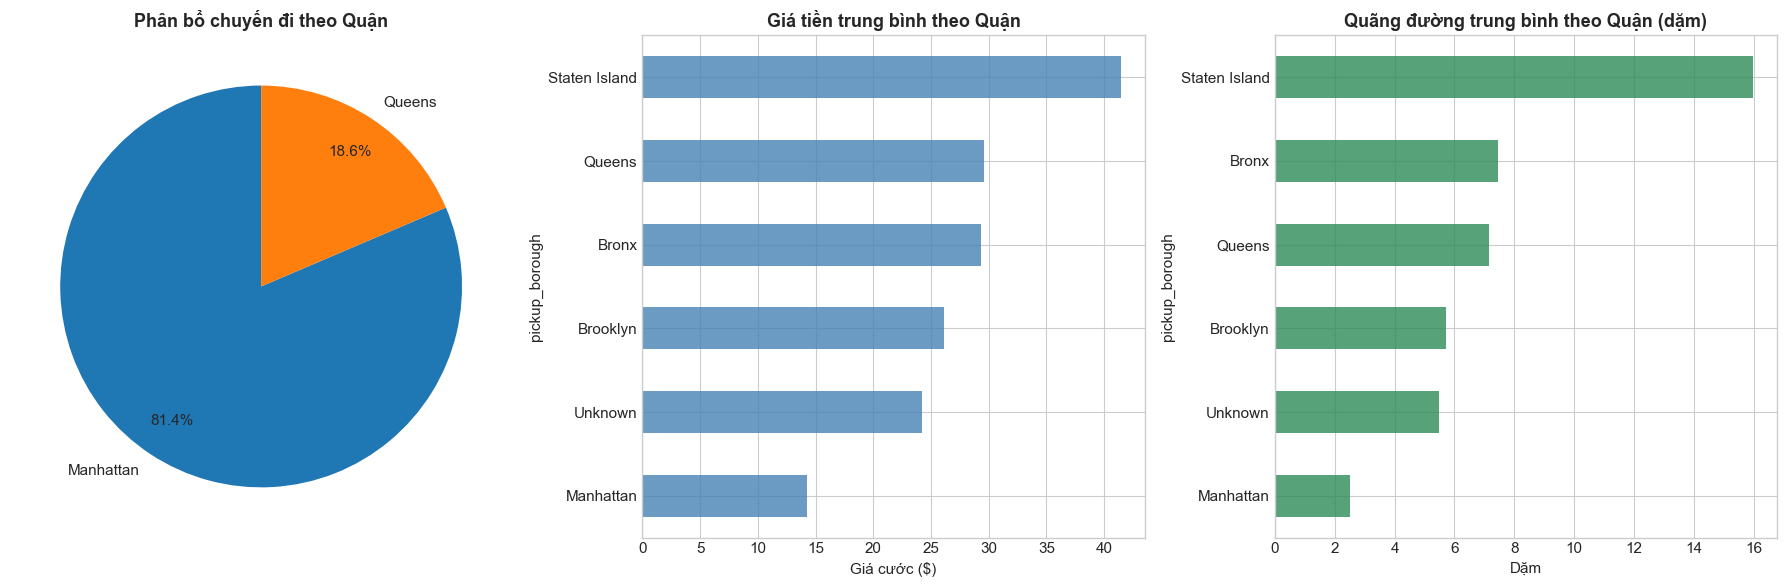

In [25]:
# --- PHÂN TÍCH THEO QUẬN ---
if 'pickup_borough' in df_clean.columns:
    borough_stats = df_clean.groupby('pickup_borough').agg(
        so_chuyen_di=('trip_distance', 'count'),
        qu_duong_tb=('trip_distance', 'mean'),
        thoi_gian_tb=('trip_duration', 'mean'),
        gia_tien_tb=('fare_amount', 'mean'),
        tong_doanh_thu=('total_amount', 'sum'),
    ).round(2).sort_values('so_chuyen_di', ascending=False)

    borough_stats['phan_tram_chuyen'] = (borough_stats['so_chuyen_di'] /
                                         borough_stats['so_chuyen_di'].sum() * 100).round(2)

    print('--- THỐNG KÊ THEO QUẬN (BOROUGH) ---')
    print(borough_stats.to_string())
    print()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Biểu đồ tròn phân bổ chuyến đi
    top_bor = borough_stats[borough_stats['phan_tram_chuyen'] > 1]
    axes[0].pie(top_bor['so_chuyen_di'],
                labels=top_bor.index,
                autopct='%1.1f%%',
                startangle=90,
                pctdistance=0.8)
    axes[0].set_title('Phân bổ chuyến đi theo Quận')

    # Giá tiền trung bình theo quận
    borough_stats['gia_tien_tb'].sort_values().plot(
        kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
    axes[1].set_title('Giá tiền trung bình theo Quận')
    axes[1].set_xlabel('Giá cước ($)')

    # Quãng đường trung bình theo quận
    borough_stats['qu_duong_tb'].sort_values().plot(
        kind='barh', ax=axes[2], color='seagreen', alpha=0.8)
    axes[2].set_title('Quãng đường trung bình theo Quận (dặm)')
    axes[2].set_xlabel('Dặm')

    plt.tight_layout()
    plt.show()

--- MA TRẬN OD SỐ CHUYẾN ĐI GIỮA CÁC QUẬN ---
dropoff_borough  Bronx  Brooklyn  Manhattan  Queens  Staten Island  Unknown
pickup_borough                                                             
Bronx              206        72        499     265              0       32
Brooklyn            65       615       1377     691              1       20
Manhattan         1209      4789     320148   51059             34     1207
Queens             923      3707      61144   19194             34     1357
Staten Island        0         0          8       1              2        0
Unknown             56        73       1241     395              3     1574

--- MA TRẬN OD TỶ LỆ % THEO QUẬN XUẤT PHÁT ---
dropoff_borough   Bronx  Brooklyn  Manhattan  Queens  Staten Island  Unknown
pickup_borough                                                              
Bronx           19.1800    6.7000    46.4600 24.6700         0.0000   2.9800
Brooklyn         2.3500   22.2100    49.7300 24.9500         0.0400

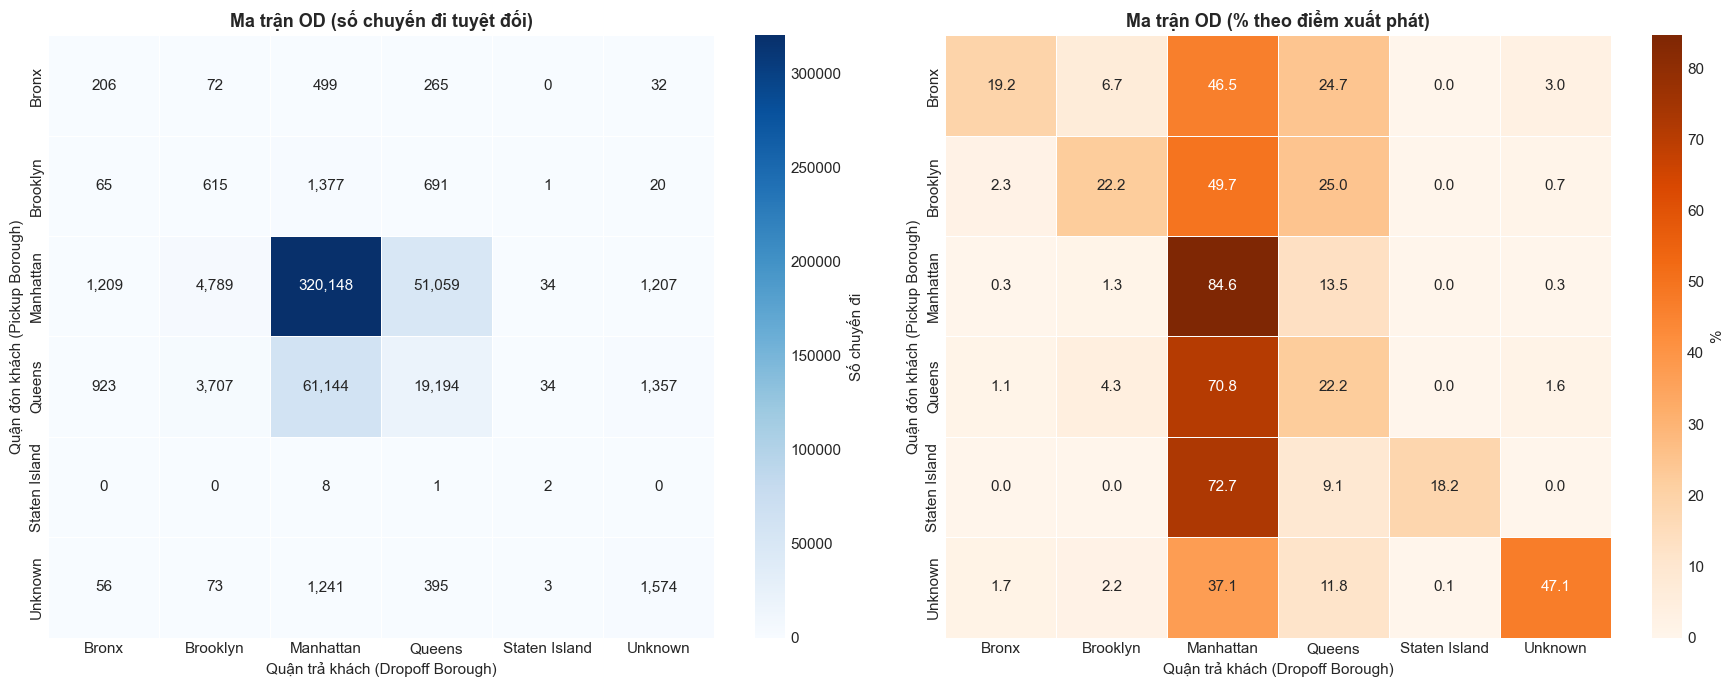

--- TOP 20 TUYẾN PU-DO ZONE CÓ MẬT ĐỘ CAO NHẤT ---
 PULocationID  DOLocationID  count
          237           236   3274
          236           237   2750
          237           237   2187
          236           236   2129
          264           264   1506
          161           237   1409
          237           161   1372
          142           239   1218
          239           238   1199
          239           142   1183
          237           162   1181
          161           236   1175
          141           236   1077
          236           161   1038
          237           141   1033
          238           239   1015
          142           238    973
          236           141    940
          186           230    932
          162           237    924


In [26]:
# --- LUỒNG DI CHUYỂN O-D (ORIGIN-DESTINATION) THEO QUẬN ---
if 'pickup_borough' in df_clean.columns and 'dropoff_borough' in df_clean.columns:
    od_matrix = df_clean.groupby(['pickup_borough', 'dropoff_borough']).size().unstack(fill_value=0)
    od_pct    = od_matrix.div(od_matrix.sum(axis=1), axis=0) * 100

    print('--- MA TRẬN OD SỐ CHUYẾN ĐI GIỮA CÁC QUẬN ---')
    print(od_matrix.to_string())
    print()
    print('--- MA TRẬN OD TỶ LỆ % THEO QUẬN XUẤT PHÁT ---')
    print(od_pct.round(2).to_string())
    print()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(od_matrix, annot=True, fmt=',.0f', cmap='Blues',
                linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Số chuyến đi'})
    axes[0].set_title('Ma trận OD (số chuyến đi tuyệt đối)')
    axes[0].set_xlabel('Quận trả khách (Dropoff Borough)')
    axes[0].set_ylabel('Quận đón khách (Pickup Borough)')

    sns.heatmap(od_pct.round(1), annot=True, fmt='.1f', cmap='Oranges',
                linewidths=0.5, ax=axes[1], cbar_kws={'label': '%'})
    axes[1].set_title('Ma trận OD (% theo điểm xuất phát)')
    axes[1].set_xlabel('Quận trả khách (Dropoff Borough)')
    axes[1].set_ylabel('Quận đón khách (Pickup Borough)')

    plt.tight_layout()
    plt.show()

    # Top tuyến PU-DO zone cụ thể
    if 'PULocationID' in df_clean.columns:
        top_od_zones = (df_clean.groupby(['PULocationID', 'DOLocationID'])
                        .size().reset_index(name='count')
                        .sort_values('count', ascending=False).head(20))
        print('--- TOP 20 TUYẾN PU-DO ZONE CÓ MẬT ĐỘ CAO NHẤT ---')
        print(top_od_zones.to_string(index=False))

**Nhận xét 6 - Không gian**

* Manhattan là trung tâm tuyệt đối của hệ thống: chiếm ~80% tổng số chuyến, đồng thời cũng là điểm đến chính của hầu hết các quận khác (≥45–70% luồng đổ về).
* Các zone hotspot tập trung chủ yếu ở Manhattan (các ID như 237, 236, 161, 132), xuất hiện nhất quán trong top pickup và dropoff qua nhiều năm → đây là các khu vực lõi kinh tế/du lịch.
* Queens đứng thứ hai (~18%), có đặc điểm chuyến đi dài hơn (distance, duration, fare cao hơn Manhattan) → phù hợp với vai trò kết nối sân bay và vùng ngoại vi.
* Các quận Brooklyn, Bronx và Staten Island có tỷ trọng rất nhỏ (<1%), nhưng có xu hướng:
  * Khoảng cách và thời gian chuyến đi dài hơn
  * Phụ thuộc mạnh vào Manhattan làm điểm đến
* Ma trận OD cho thấy:
  * Phần lớn chuyến đi là nội bộ Manhattan (~85%) → nhu cầu di chuyển dày đặc trong khu vực trung tâm
  * Các luồng lớn tiếp theo là Queens ↔ Manhattan và Brooklyn → Manhattan
  * Luồng giữa các quận ngoại vi với nhau khá thấp
* Các tuyến OD mật độ cao chủ yếu là:
  * Nội vùng Manhattan (zone → chính nó hoặc lân cận)
  * Các cặp zone trung tâm Manhattan với nhau (237 ↔ 236, 161 ↔ 237, …)
* Kết luận:
  * Manhattan là hub trung tâm cả về cung và cầu
  * Hệ thống có cấu trúc “hub-and-spoke”: các quận ngoại vi kết nối về Manhattan
  * Phân tích hoặc mô hình hóa cần xem xét yếu tố không gian mạnh, đặc biệt là zone-level thay vì chỉ borough-level


---
<a id='5-trip-finance'></a>
## 7. Chuyến đi & Tài chính

  PHÂN PHỐI QUÃNG ĐƯỜNG (trip_distance)
count   472,001.0000
mean          3.4060
std           4.3240
min           0.0100
10%           0.7000
25%           1.1000
50%           1.8300
75%           3.4900
90%           8.5900
95%          13.4400
99%          19.9300
max         143.0500

--- PHÂN BỔ THEO KHOẢNG QUÃNG ĐƯỜNG (%) ---
distance_bucket
0-0.5     4.5100
0.5-1    17.7000
1-2      32.2600
2-3      16.2100
3-5      12.2300
5-10      9.3000
10-20     6.8200
20-50     0.9600
50-150    0.0100

  PHÂN PHỐI THỜI GIAN DI CHUYỂN (trip_duration - phút)
count   472,001.0000
mean         15.9530
std          12.9880
min           0.0170
10%           4.7500
25%           7.5500
50%          12.3670
75%          19.9830
90%          31.0670
95%          41.1170
99%          65.9500
max         291.6670

--- PHÂN BỔ THEO KHOẢNG THỜI GIAN (%) ---
duration_bucket
0-5       11.2300
5-10      27.3000
10-15     22.0600
15-20     14.5000
20-30     14.0700
30-45      6.9200
45-60      2.4300
6

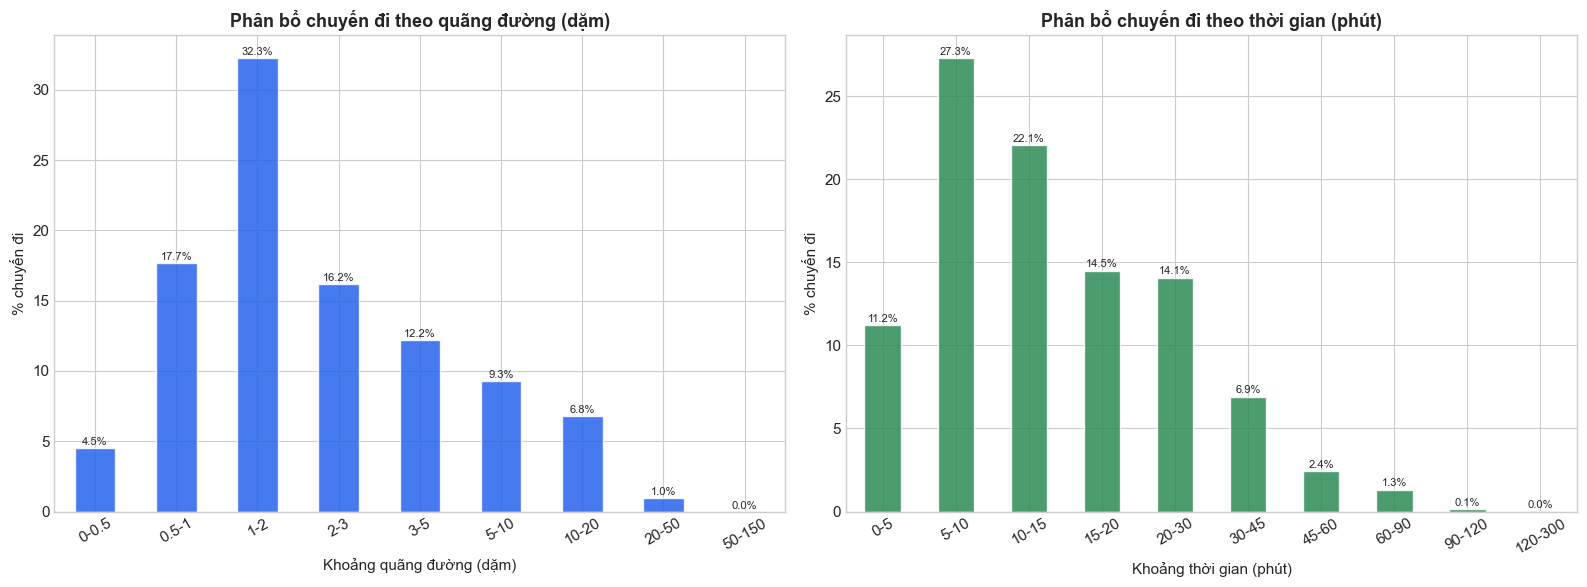

In [27]:
# --- PHÂN PHỐI QUÃNG ĐƯỜNG VÀ THỜI GIAN DI CHUYỂN ---
print('===================================================')
print('  PHÂN PHỐI QUÃNG ĐƯỜNG (trip_distance)')
print('===================================================')
print(df_clean['trip_distance'].describe(percentiles=[0.1,0.25,0.5,0.75,0.9,0.95,0.99]).round(3).to_string())

dist_bins = [0, 0.5, 1, 2, 3, 5, 10, 20, 50, 150]
dist_labels = ['0-0.5','0.5-1','1-2','2-3','3-5','5-10','10-20','20-50','50-150']
df_clean['distance_bucket'] = pd.cut(df_clean['trip_distance'], bins=dist_bins, labels=dist_labels)
dist_pct = df_clean['distance_bucket'].value_counts(normalize=True).sort_index() * 100
print('\n--- PHÂN BỔ THEO KHOẢNG QUÃNG ĐƯỜNG (%) ---')
print(dist_pct.round(2).to_string())
print()

print('===================================================')
print('  PHÂN PHỐI THỜI GIAN DI CHUYỂN (trip_duration - phút)')
print('===================================================')
print(df_clean['trip_duration'].describe(percentiles=[0.1,0.25,0.5,0.75,0.9,0.95,0.99]).round(3).to_string())

dur_bins = [0, 5, 10, 15, 20, 30, 45, 60, 90, 120, 300]
dur_labels = ['0-5','5-10','10-15','15-20','20-30','30-45','45-60','60-90','90-120','120-300']
df_clean['duration_bucket'] = pd.cut(df_clean['trip_duration'], bins=dur_bins, labels=dur_labels)
dur_pct = df_clean['duration_bucket'].value_counts(normalize=True).sort_index() * 100
print('\n--- PHÂN BỔ THEO KHOẢNG THỜI GIAN (%) ---')
print(dur_pct.round(2).to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dist_pct.plot(kind='bar', ax=axes[0], color=COLOR_PRIMARY, alpha=0.85, edgecolor='white')
axes[0].set_title('Phân bổ chuyến đi theo quãng đường (dặm)')
axes[0].set_xlabel('Khoảng quãng đường (dặm)')
axes[0].set_ylabel('% chuyến đi')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(dist_pct):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=8)

dur_pct.plot(kind='bar', ax=axes[1], color='seagreen', alpha=0.85, edgecolor='white')
axes[1].set_title('Phân bổ chuyến đi theo thời gian (phút)')
axes[1].set_xlabel('Khoảng thời gian (phút)')
axes[1].set_ylabel('% chuyến đi')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(dur_pct):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [28]:
# --- PHÂN TÍCH GIÁ TIỀN: CƯỚC PHÍ, TIỀN TÍP, PHÍ CẦU ĐƯỜNG, TỔNG CỘNG ---
fin_cols = ['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount', 'tip_pct']
fin_cols = [c for c in fin_cols if c in df_clean.columns]

print('===================================================')
print('  THỐNG KÊ TÀI CHÍNH CHUYẾN ĐI')
print('===================================================')
print(df_clean[fin_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(3).to_string())
print()

# Cấu trúc doanh thu
revenue_struct = {
    'Giá cước (Fare)': df_clean['fare_amount'].mean(),
    'Tiền típ (Tip)': df_clean['tip_amount'].mean() if 'tip_amount' in df_clean.columns else 0,
    'Phí cầu đường (Tolls)': df_clean['tolls_amount'].mean() if 'tolls_amount' in df_clean.columns else 0,
    'Phí khác (Extra/Misc)': (df_clean['total_amount'] - df_clean['fare_amount']
                              - df_clean.get('tip_amount', 0) - df_clean.get('tolls_amount', 0)).mean(),
}
print('--- CẤU TRÚC DOANH THU TRUNG BÌNH MỖI CHUYẾN ĐI ---')
total_avg = sum(revenue_struct.values())
for k, v in revenue_struct.items():
    print(f'  {k:<22}: ${v:.2f} ({v/total_avg*100:.1f}%)')
print(f'  {"TỔNG CỘNG":22}: ${total_avg:.2f}')
print()

# Tỷ lệ tiền típ: số chuyến có típ / không có típ
tip_rate = (df_clean['tip_amount'] > 0).mean() * 100 if 'tip_amount' in df_clean.columns else None
if tip_rate:
    print(f'  Tỷ lệ chuyến đi có tiền típ: {tip_rate:.1f}%')
    print(f'  Tiền típ trung bình (khi có típ): ${df_clean[df_clean["tip_amount"] > 0]["tip_amount"].mean():.2f}')
    tip_rate_by_year = df_clean.groupby('year').apply(
        lambda x: (x['tip_amount'] > 0).mean() * 100
    )
    print('  Tỷ lệ có tiền típ theo năm:')
    print(tip_rate_by_year.round(2).to_string())

  THỐNG KÊ TÀI CHÍNH CHUYẾN ĐI
       fare_amount   tip_amount  tolls_amount  total_amount      tip_pct
count 472,001.0000 472,001.0000  472,001.0000  472,001.0000 472,001.0000
mean       17.2710       2.9610        0.5170       25.1240      19.4850
std        15.8840       3.7000        2.0270       20.0080      18.8510
min         0.0100       0.0000        0.0000        0.3100       0.0000
10%         5.8000       0.0000        0.0000       10.9200       0.0000
25%         8.0000       0.0000        0.0000       13.8000       0.0000
50%        12.1000       2.3000        0.0000       18.8000      23.5290
75%        19.8000       3.8000        0.0000       27.3700      29.2440
90%        35.2400       6.2400        0.0000       47.0000      35.1160
95%        52.0000      10.0000        6.5500       70.9200      39.6080
99%        70.0000      16.5400        6.9400       99.7800      52.0000
max       500.0000     338.0000       66.0000      535.8100   4,506.6670

--- CẤU TRÚC DOANH 

--- SỐ LIỆU BIỂU ĐỒ: Giá cước trung bình theo năm ---
        mean  median     std
year                        
2020 12.4600  9.0000 10.8500
2021 13.4200  9.5000 11.9100
2022 14.7800 10.5000 13.2500
2023 19.8500 13.5000 17.8100
2024 19.9100 14.2000 17.8000
2025 20.1000 14.4300 17.5000

--- SỐ LIỆU BOXPLOT: Giá cước theo năm (trung vị, Q1, Q3, whiskers) ---
           count    mean     std    min    25%     50%     75%      max
year                                                                   
2020 52,909.0000 12.4600 10.8500 0.0100 6.5000  9.0000 14.0000 250.0000
2021 66,132.0000 13.4200 11.9100 0.0100 6.5000  9.5000 15.0000 400.0000
2022 84,999.0000 14.7800 13.2500 0.0100 7.0000 10.5000 16.5000 280.0000
2023 81,840.0000 19.8500 17.8100 0.0100 9.3000 13.5000 21.9000 382.4000
2024 87,851.0000 19.9100 17.8000 0.0100 9.3000 14.2000 22.6000 497.0000
2025 98,270.0000 20.1000 17.5000 0.0100 9.3000 14.4300 23.5500 500.0000

--- SỐ LIỆU BIỂU ĐỒ: Phân bổ % Tiền típ ---
tip_pct
0 (không típ

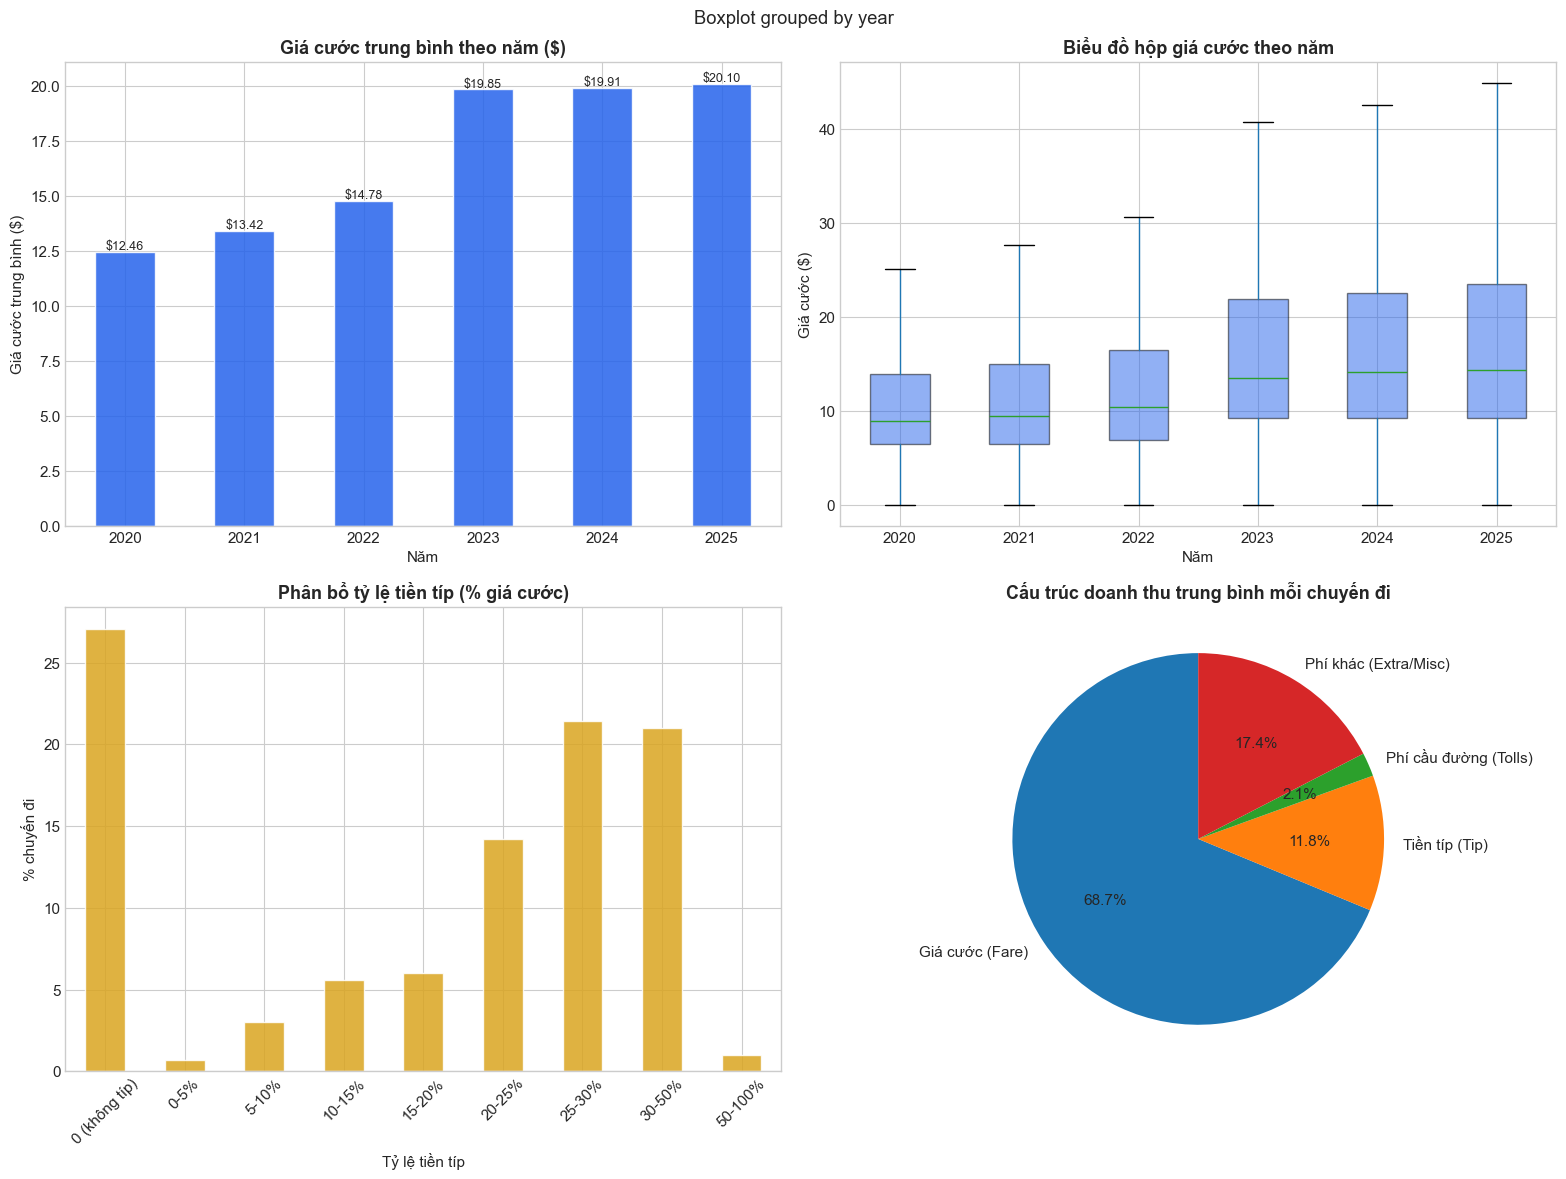

In [29]:
# --- BIỂU ĐỒ TÀI CHÍNH ---
print('--- SỐ LIỆU BIỂU ĐỒ: Giá cước trung bình theo năm ---')
fare_by_year = df_clean.groupby('year')['fare_amount'].agg(['mean','median','std']).round(2)
print(fare_by_year.to_string())
print()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Giá cước trung bình theo năm
fare_by_year['mean'].plot(kind='bar', ax=axes[0,0], color=COLOR_PRIMARY, alpha=0.85, edgecolor='white')
axes[0,0].set_title('Giá cước trung bình theo năm ($)')
axes[0,0].set_xlabel('Năm')
axes[0,0].set_ylabel('Giá cước trung bình ($)')
axes[0,0].tick_params(axis='x', rotation=0)
for i, v in enumerate(fare_by_year['mean']):
    axes[0,0].text(i, v + 0.1, f'${v:.2f}', ha='center', fontsize=9)

# Biểu đồ hộp (Boxplot) giá cước theo năm
print('--- SỐ LIỆU BOXPLOT: Giá cước theo năm (trung vị, Q1, Q3, whiskers) ---')
fare_boxstats = df_clean.groupby('year')['fare_amount'].describe(percentiles=[0.25,0.5,0.75]).round(2)
print(fare_boxstats.to_string())
print()
df_clean.boxplot(column='fare_amount', by='year', ax=axes[0,1],
                  showfliers=False, patch_artist=True,
                  boxprops=dict(facecolor=COLOR_PRIMARY, alpha=0.5))
axes[0,1].set_title('Biểu đồ hộp giá cước theo năm (không bao gồm giá trị ngoại lai)')
axes[0,1].set_xlabel('Năm')
axes[0,1].set_ylabel('Giá cước ($)')
plt.sca(axes[0,1])
plt.title('Biểu đồ hộp giá cước theo năm')

# Phân bổ tỷ lệ tiền típ
if 'tip_pct' in df_clean.columns:
    tip_valid = df_clean[df_clean['tip_pct'].between(0, 100)]['tip_pct']
    tip_pct_bins = [0, 0.01, 5, 10, 15, 20, 25, 30, 50, 100]
    tip_pct_labels = ['0 (không típ)','0-5%','5-10%','10-15%','15-20%','20-25%','25-30%','30-50%','50-100%']
    tip_dist = pd.cut(df_clean['tip_pct'].fillna(0), bins=[-0.01]+tip_pct_bins[1:],
                      labels=tip_pct_labels).value_counts(normalize=True).sort_index() * 100
    print('--- SỐ LIỆU BIỂU ĐỒ: Phân bổ % Tiền típ ---')
    print(tip_dist.round(2).to_string())
    print()
    tip_dist.plot(kind='bar', ax=axes[1,0], color='goldenrod', alpha=0.85, edgecolor='white')
    axes[1,0].set_title('Phân bổ tỷ lệ tiền típ (% giá cước)')
    axes[1,0].set_xlabel('Tỷ lệ tiền típ')
    axes[1,0].set_ylabel('% chuyến đi')
    axes[1,0].tick_params(axis='x', rotation=45)

# Biểu đồ tròn cấu trúc doanh thu
# Giả sử revenue_struct đã được chuẩn hóa tiếng Việt ở bước trước
rev_series = pd.Series({k: max(0, v) for k, v in revenue_struct.items() if v > 0})
axes[1,1].pie(rev_series, labels=rev_series.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Cấu trúc doanh thu trung bình mỗi chuyến đi')

plt.tight_layout()
plt.show()

  PHÂN BỔ SỐ KHÁCH TRÊN MỘT CHUYẾN ĐI
  1 khách: 76.77%
  2 khách: 14.95%
  3 khách: 3.72%
  4 khách: 1.94%
  5 khách: 1.59%
  6 khách: 1.03%

  Đi một mình (1 khách)     : 76.77%
  Đi nhóm (2+ khách)        : 23.23%

--- SỐ KHÁCH TRUNG BÌNH THEO NĂM ---
       mean  median
year               
2020 1.5040  1.0000
2021 1.4600  1.0000
2022 1.4280  1.0000
2023 1.3910  1.0000
2024 1.3490  1.0000
2025 1.3010  1.0000
--- TỶ LỆ ĐI MỘT MÌNH THEO NĂM ---
year
2020   72.4400
2021   71.4200
2022   72.9900
2023   74.2200
2024   70.7800
2025   63.7000

--- GIÁ CƯỚC TRUNG BÌNH THEO SỐ KHÁCH ---
passenger_count
1.0000   16.4500
2.0000   18.6000
3.0000   18.0400
4.0000   20.6700
5.0000   14.7800
6.0000   15.1000



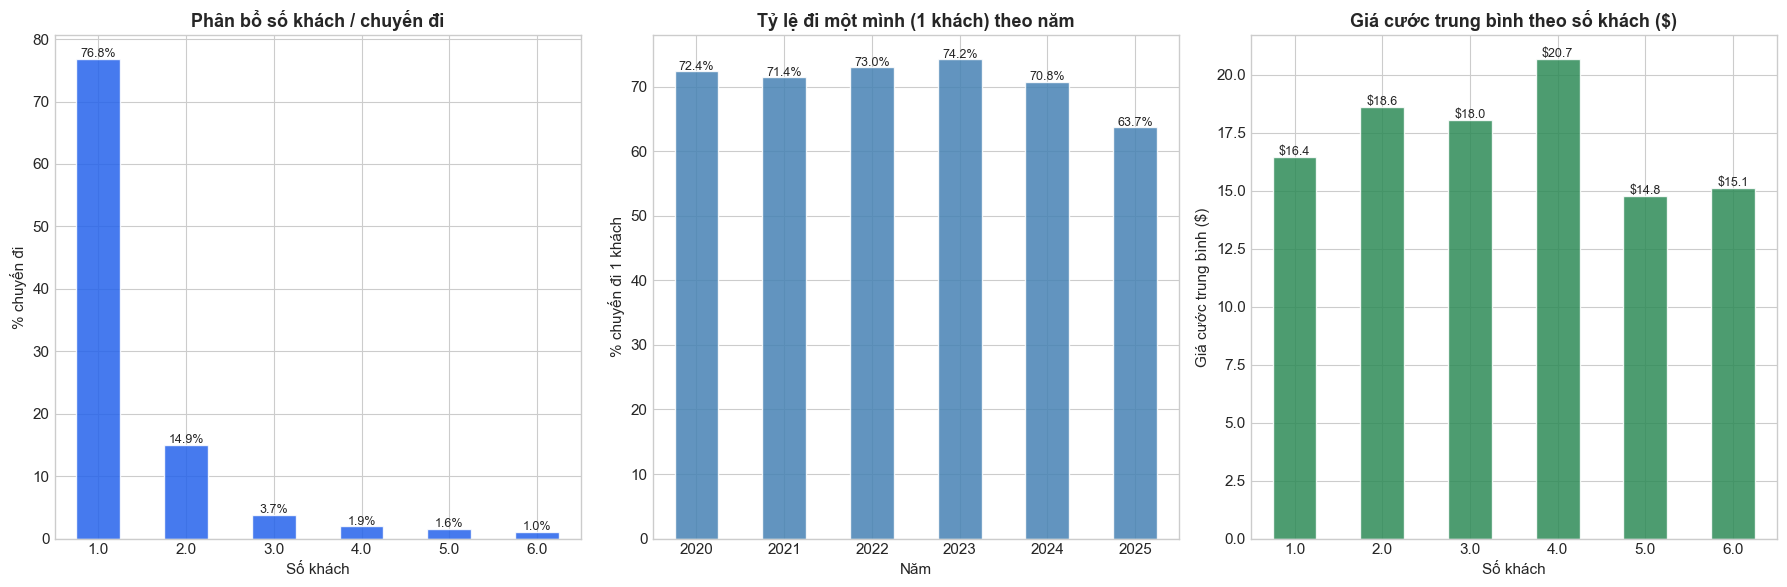

In [30]:
# --- THÓI QUEN ĐI XE: SỐ KHÁCH / CHUYẾN ---
if 'passenger_count' in df_clean.columns:
    pax_dist = df_clean['passenger_count'].value_counts().sort_index()
    pax_pct  = (pax_dist / pax_dist.sum() * 100).round(2)

    print('===================================================')
    print('  PHÂN BỔ SỐ KHÁCH TRÊN MỘT CHUYẾN ĐI')
    print('===================================================')
    for k, v in pax_pct.items():
        print(f'  {int(k)} khách: {v:.2f}%')
    solo_rate = pax_pct.get(1, 0)
    group_rate = pax_pct[pax_pct.index > 1].sum()
    print(f'\n  Đi một mình (1 khách)     : {solo_rate:.2f}%')
    print(f'  Đi nhóm (2+ khách)        : {group_rate:.2f}%')
    print()

    # Số khách theo năm
    pax_by_year = df_clean.groupby('year')['passenger_count'].agg(['mean','median']).round(3)
    solo_by_year = df_clean.groupby('year').apply(
        lambda x: (x['passenger_count'] == 1).mean() * 100
    ).round(2)
    print('--- SỐ KHÁCH TRUNG BÌNH THEO NĂM ---')
    print(pax_by_year.to_string())
    print('--- TỶ LỆ ĐI MỘT MÌNH THEO NĂM ---')
    print(solo_by_year.to_string())
    print()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    pax_pct.plot(kind='bar', ax=axes[0], color=COLOR_PRIMARY, edgecolor='white', alpha=0.85)
    for i, v in enumerate(pax_pct):
        axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
    axes[0].set_title('Phân bổ số khách / chuyến đi')
    axes[0].set_xlabel('Số khách')
    axes[0].set_ylabel('% chuyến đi')
    axes[0].tick_params(axis='x', rotation=0)

    solo_by_year.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white', alpha=0.85)
    for i, v in enumerate(solo_by_year):
        axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)
    axes[1].set_title('Tỷ lệ đi một mình (1 khách) theo năm')
    axes[1].set_xlabel('Năm')
    axes[1].set_ylabel('% chuyến đi 1 khách')
    axes[1].tick_params(axis='x', rotation=0)

    # Giá cước trung bình theo số khách
    fare_by_pax = df_clean.groupby('passenger_count')['fare_amount'].mean().round(2)
    print('--- GIÁ CƯỚC TRUNG BÌNH THEO SỐ KHÁCH ---')
    print(fare_by_pax.to_string())
    print()
    fare_by_pax.plot(kind='bar', ax=axes[2], color='seagreen', edgecolor='white', alpha=0.85)
    for i, v in enumerate(fare_by_pax):
        axes[2].text(i, v + 0.1, f'${v:.1f}', ha='center', fontsize=9)
    axes[2].set_title('Giá cước trung bình theo số khách ($)')
    axes[2].set_xlabel('Số khách')
    axes[2].set_ylabel('Giá cước trung bình ($)')
    axes[2].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
else:
    print('Không có cột passenger_count trong dữ liệu.')

--- PHÂN BỔ PHƯƠNG THỨC THANH TOÁN ---
payment_label
Thẻ tín dụng   74.3300
Tiền mặt       16.6700
Khác            8.0600
Tranh chấp      0.6200
Miễn phí        0.3200

--- TỶ LỆ PHƯƠNG THỨC THANH TOÁN THEO NĂM (%) ---
payment_label    Khác  Miễn phí  Thẻ tín dụng  Tiền mặt  Tranh chấp
year                                                               
2020           3.2700    0.3300       71.1100   25.1500      0.1500
2021           4.7700    0.2600       73.3600   21.5100      0.1100
2022           3.3000    0.2700       76.9700   19.2700      0.2000
2023           2.7400    0.3500       79.5900   16.6700      0.6500
2024           9.3700    0.3400       76.0100   13.3100      0.9600
2025          20.2500    0.3800       68.5500    9.5900      1.2300



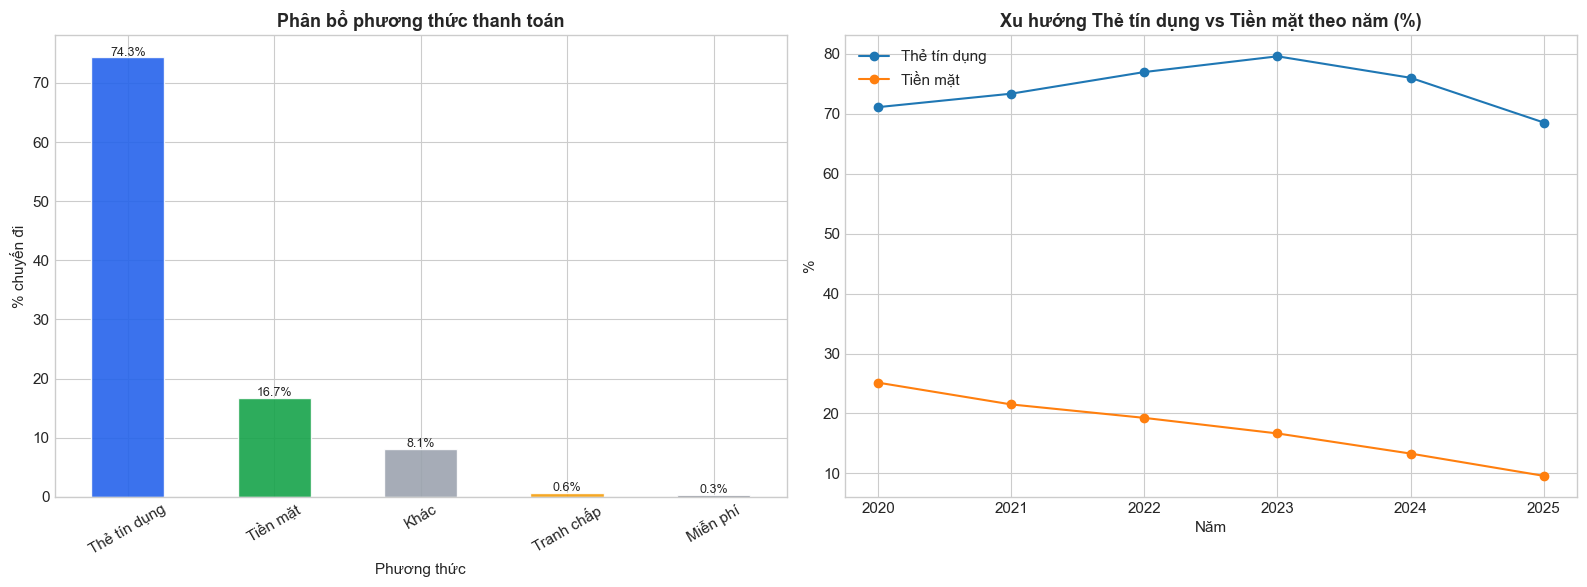

In [31]:
# --- PHƯƠNG THỨC THANH TOÁN ---
if 'payment_type' in df_clean.columns:
    PAY_MAP = {1: 'Thẻ tín dụng', 2: 'Tiền mặt', 3: 'Miễn phí', 4: 'Tranh chấp', 5: 'Không xác định', 6: 'Bị hủy'}
    df_clean['payment_label'] = df_clean['payment_type'].map(PAY_MAP).fillna('Khác')

    pay_dist = df_clean['payment_label'].value_counts()
    pay_pct  = (pay_dist / pay_dist.sum() * 100).round(2)
    print('--- PHÂN BỔ PHƯƠNG THỨC THANH TOÁN ---')
    print(pay_pct.to_string())
    print()

    # Xu hướng theo năm
    pay_by_year = df_clean.groupby(['year', 'payment_label']).size().unstack(fill_value=0)
    pay_pct_year = pay_by_year.div(pay_by_year.sum(axis=1), axis=0) * 100
    print('--- TỶ LỆ PHƯƠNG THỨC THANH TOÁN THEO NĂM (%) ---')
    print(pay_pct_year.round(2).to_string())
    print()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    pay_pct.plot(kind='bar', ax=axes[0], color=['#2563EB','#16A34A','#9CA3AF','#F59E0B','#6B7280'],
                  edgecolor='white', alpha=0.9)
    for i, v in enumerate(pay_pct):
        axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
    axes[0].set_title('Phân bổ phương thức thanh toán')
    axes[0].set_xlabel('Phương thức')
    axes[0].set_ylabel('% chuyến đi')
    axes[0].tick_params(axis='x', rotation=30)

    # Đảm bảo hiển thị đúng tên nhãn mới trong biểu đồ đường
    trend_cols = [c for c in ['Thẻ tín dụng', 'Tiền mặt'] if c in pay_pct_year.columns]
    pay_pct_year[trend_cols].plot(kind='line', marker='o', ax=axes[1])
    axes[1].set_title('Xu hướng Thẻ tín dụng vs Tiền mặt theo năm (%)')
    axes[1].set_xlabel('Năm')
    axes[1].set_ylabel('%')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('Không có cột payment_type trong dữ liệu.')

--- GIÁ TIỀN / DẶM VÀ / PHÚT THEO NĂM ---
     fare_per_mile        fare_per_min       
              mean median         mean median
year                                         
2020        8.7500 5.2630       1.4190 0.9330
2021        7.6180 5.0750       1.2700 0.9210
2022        8.4210 5.1890       1.3880 0.8900
2023       11.6630 7.1290       1.7300 1.1490
2024       13.8760 7.3370       1.9900 1.1310
2025       20.3180 7.2220       2.1580 1.1320

--- THỐNG KÊ TỔNG HỢP GIÁ TIỀN / DẶM ---
count   472,001.0000
mean         12.4000
std         151.5100
min           0.0000
10%           3.8270
50%           6.2500
90%          10.7500
max      26,300.0000



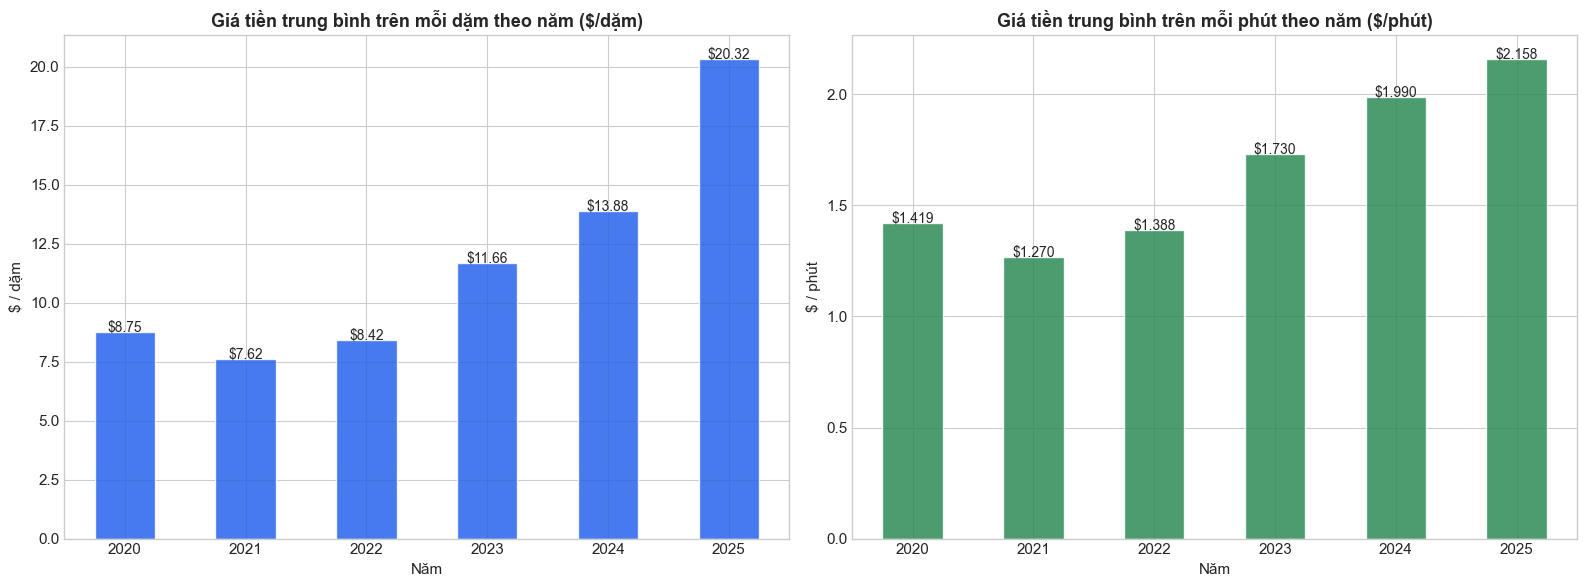

In [32]:
# --- PHÂN TÍCH HIỆU QUẢ: GIÁ TIỀN TRÊN MỖI ĐƠN VỊ ĐƯỜNG ĐI ---
df_clean['fare_per_mile'] = np.where(
    df_clean['trip_distance'] > 0,
    df_clean['fare_amount'] / df_clean['trip_distance'],
    np.nan
)
df_clean['fare_per_min'] = np.where(
    df_clean['trip_duration'] > 0,
    df_clean['fare_amount'] / df_clean['trip_duration'],
    np.nan
)

fpm_stats = df_clean.groupby('year')[['fare_per_mile', 'fare_per_min']].agg(['mean','median']).round(3)
print('--- GIÁ TIỀN / DẶM VÀ / PHÚT THEO NĂM ---')
print(fpm_stats.to_string())
print()

print('--- THỐNG KÊ TỔNG HỢP GIÁ TIỀN / DẶM ---')
print(df_clean['fare_per_mile'].describe(percentiles=[0.1,0.5,0.9]).round(3).to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fpm_stats['fare_per_mile']['mean'].plot(kind='bar', ax=axes[0], color=COLOR_PRIMARY, edgecolor='white', alpha=0.85)
axes[0].set_title('Giá tiền trung bình trên mỗi dặm theo năm ($/dặm)')
axes[0].set_xlabel('Năm')
axes[0].set_ylabel('$ / dặm')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(fpm_stats['fare_per_mile']['mean']):
    axes[0].text(i, v + 0.02, f'${v:.2f}', ha='center', fontsize=10)

fpm_stats['fare_per_min']['mean'].plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Giá tiền trung bình trên mỗi phút theo năm ($/phút)')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('$ / phút')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(fpm_stats['fare_per_min']['mean']):
    axes[1].text(i, v + 0.002, f'${v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### **Nhận xét 5.2: Phân tích hành vi chuyến đi và tài chính**

* Đặc trưng chuyến đi: phần lớn chuyến đi ngắn (median ~1.8 miles, ~12 phút), tập trung mạnh trong khoảng 1–3 miles (>48%). Điều này xác nhận nhu cầu di chuyển nội đô là chủ yếu. Phân phối lệch phải, tồn tại một số chuyến dài nhưng chiếm tỷ lệ rất nhỏ.
* Hành vi khách hàng: tỷ lệ đi một mình chiếm ưu thế (~77%) và có xu hướng giảm dần theo thời gian (còn ~64% năm 2025) → dấu hiệu gia tăng đi theo nhóm. Số khách trung bình giảm nhẹ qua các năm, phản ánh thay đổi hành vi sau COVID.
* Tài chính chuyến đi:
  * Fare chiếm phần lớn doanh thu (~69%), tiếp theo là tip (~12%) và phụ phí (~17%).
  * Tip xuất hiện trong ~73% chuyến, mức tip phổ biến nằm trong khoảng 20–30%.
  * Fare và total_amount tăng rõ rệt từ 2023 trở đi, cho thấy tác động của điều chỉnh giá và lạm phát.
* Hiệu quả giá:
  * Fare per mile và per minute tăng mạnh theo năm, đặc biệt giai đoạn 2023–2025 → chi phí di chuyển ngày càng cao.
  * Phân phối fare/mile có outlier lớn, nhưng median ổn định (~5–7), phản ánh mức giá điển hình không biến động quá mạnh.
* Phương thức thanh toán:
  * Thanh toán bằng thẻ chiếm ưu thế (~74%) và tăng dần đến 2023, sau đó giảm nhẹ do nhóm “Other” tăng mạnh năm 2025.
  * Tiền mặt giảm liên tục (từ ~25% xuống ~10%) → xu hướng số hóa thanh toán.
* Kết luận:
  * Taxi chủ yếu phục vụ nhu cầu di chuyển ngắn, cá nhân trong nội đô.
  * Doanh thu phụ thuộc chính vào fare, nhưng tip vẫn là thành phần đáng kể.
  * Giá cước có xu hướng tăng mạnh sau 2022.
  * Hành vi khách hàng và thanh toán đang thay đổi theo hướng đi nhóm nhiều hơn và ít dùng tiền mặt hơn.


---
## 8. Tổng kết, để xuất

In [33]:
# --- BẢNG TỔNG KẾT ---
print('===================================================')
print('  TỔNG KẾT EDA NYC YELLOW TAXI 2020-2025')
print('===================================================')
print(f'  Tổng số tệp phân tích               : {len(df_files)}')
print(f'  Khoảng thời gian                    : {df_files["year"].min()} - {df_files["year"].max()}')
print(f'  Tổng số chuyến đi (toàn bộ dataset) : {df_files["row_count"].sum():,}')
print(f'  Kích thước dữ liệu (nén)            : {df_files["size_mb"].sum()/1024:.2f} GB')
print(f'  Số dòng mẫu EDA                     : {len(df_clean):,}')
print(f'  Tỉ lệ dữ liệu bị loại bỏ (outlier)  : {(1 - len(df_clean)/len(df))*100:.2f}%')
print()
print('--- CÁC CHỈ SỐ CHÍNH ---')
print(f'  Giá cước trung bình                 : ${df_clean["fare_amount"].mean():.2f}')
print(f'  Quãng đường trung bình              : {df_clean["trip_distance"].mean():.2f} dặm')
print(f'  Thời gian di chuyển trung bình      : {df_clean["trip_duration"].mean():.1f} phút')
if 'avg_speed_mph' in df_clean.columns:
    print(f'  Tốc độ trung bình                   : {df_clean["avg_speed_mph"].mean():.1f} mph')
if 'tip_amount' in df_clean.columns:
    print(f'  Tỉ lệ chuyến có tiền típ            : {(df_clean["tip_amount"]>0).mean()*100:.1f}%')
if 'passenger_count' in df_clean.columns:
    print(f'  Tỉ lệ đi một mình                   : {(df_clean["passenger_count"]==1).mean()*100:.1f}%')
print()

  TỔNG KẾT EDA NYC YELLOW TAXI 2020-2025
  Tổng số tệp phân tích               : 72
  Khoảng thời gian                    : 2020 - 2025
  Tổng số chuyến đi (toàn bộ dataset) : 223,412,046
  Kích thước dữ liệu (nén)            : 3.38 GB
  Số dòng mẫu EDA                     : 472,001
  Tỉ lệ dữ liệu bị loại bỏ (outlier)  : 5.59%

--- CÁC CHỈ SỐ CHÍNH ---
  Giá cước trung bình                 : $17.27
  Quãng đường trung bình              : 3.41 dặm
  Thời gian di chuyển trung bình      : 16.0 phút
  Tốc độ trung bình                   : 11.6 mph
  Tỉ lệ chuyến có tiền típ            : 73.0%
  Tỉ lệ đi một mình                   : 70.6%




#### **Các phát hiện chính:**
- **Tác động của COVID-19**: Đại dịch đã gây ra sự sụt giảm lịch sử vào tháng 4/2020 (giảm 96% số lượng chuyến đi). Tuy nhiên, thị trường đã có sự phục hồi mạnh mẽ và ổn định trở lại từ năm 2023.
- **Mô hình di chuyển**: Manhattan vẫn là lõi hoạt động chính. Các khung giờ cao điểm sáng (8-9h) và chiều tối (17-19h) là những thời điểm có nhu cầu cao nhất, tạo ra cơ hội tối ưu hóa doanh thu cho tài xế.
- **Hiệu quả tài chính**: Doanh thu taxi phụ thuộc chặt chẽ vào quãng đường. Tiền tip là một phần quan trọng trong thu nhập của tài xế, với tỉ lệ trung bình đạt khoảng 73% số chuyến đi có tip.
- **Chất lượng dữ liệu**: Bộ dữ liệu rất đồ sộ và nhất quán về cấu trúc, tuy nhiên cần lưu ý xử lý dữ liệu thiếu ở các trường nhập thủ công như số hành khách.